# 🌾 FarmTech Solutions — Previsão de Rendimento de Safras com Machine Learning

---

<div style="background:#f0f7ff;padding:18px;border-radius:10px;border-left:5px solid #1565c0;">

| | |
|---|---|
| **Projeto** | Fase 5 — Machine Learning na Cabeça (FIAP) |
| **Dataset** | `crop_yield.csv` — 156 registros, 4 culturas, 5 variáveis |
| **Problema** | Regressão supervisionada + Clusterização não supervisionada |
| **Linguagem** | Python 3.10 · scikit-learn · pandas · matplotlib · seaborn |

</div>

> *"Da precipitação ao prato: transformando dados climáticos em inteligência agrícola de precisão."*

---


## 1. Introdução e Contextualização

A **FarmTech Solutions** foi contratada para prestar serviços de Inteligência Artificial a uma fazenda de médio porte (~200 hectares, aprox. 210 campos de futebol oficiais) localizada em região tropical, que produz quatro culturas distintas: **Cacau, Palma de óleo (dendê), Arroz e Borracha natural**.

O desafio central é duplo:

**1. Análise de tendências** — Identificar padrões e agrupamentos naturais nas condições climáticas/edafológicas do dataset, incluindo cenários discrepantes (outliers).

**2. Previsão de rendimento** — Construir e comparar cinco modelos de regressão supervisionada que, dadas as variáveis climáticas e o tipo de cultura, prevejam o rendimento esperado da safra em hg/ha (hectogramas por hectare).

### Sobre o Dataset

O arquivo `crop_yield.csv` contém **156 observações** (39 por cultura) com as seguintes variáveis:

| Variável | Descrição | Tipo |
|----------|-----------|------|
| `Crop` | Nome da cultura agrícola | Categórica |
| `Precipitation (mm day-1)` | Precipitação em mm/dia | Numérica contínua |
| `Specific Humidity at 2 Meters (g/kg)` | Umidade específica a 2m de altura | Numérica contínua |
| `Relative Humidity at 2 Meters (%)` | Umidade relativa a 2m de altura | Numérica contínua |
| `Temperature at 2 Meters (C)` | Temperatura em °C a 2m de altura | Numérica contínua |
| `Yield` | **Rendimento em hg/ha** ← variável alvo | Numérica contínua |

> **Nota importante sobre unidades:** O rendimento (`Yield`) está em **hectogramas por hectare (hg/ha)**, não em toneladas. Isso explica as ordens de grandeza observadas (5.249 a 203.399 hg/ha).


## 2. Objetivos Técnicos

- ✅ Realizar **Análise Exploratória de Dados (EDA)** completa com estatísticas descritivas, correlações e visualizações interpretativas
- ✅ Aplicar **Machine Learning Não Supervisionado** (K-Means + DBSCAN) para identificar tendências e cenários discrepantes
- ✅ Construir **5 modelos de regressão supervisionada** com algoritmos distintos
- ✅ Avaliar modelos com métricas pertinentes: **R², RMSE e MAE**
- ✅ Aplicar **boas práticas de ML**: separação treino/teste, cross-validation, normalização
- ✅ Comparar modelos, justificar a escolha do melhor e discutir overfitting/underfitting


## 3. Importação de Bibliotecas

In [1]:
# ── Manipulação de dados ─────────────────────────────────────────────────────
import numpy as np                          # operações numéricas vetorizadas
import pandas as pd                         # DataFrames e manipulação tabular

# ── Visualização ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt             # base de plots
import matplotlib.patches as mpatches
import seaborn as sns                       # visualizações estatísticas elegantes

# ── Pré-processamento ────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# ── Clusterização ────────────────────────────────────────────────────────────
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA       # redução dimensional para visualização

# ── Modelos de Regressão ─────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# ── Métricas de avaliação ────────────────────────────────────────────────────
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ── Utilitários ──────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# Configurações globais de visualização
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.figsize': (10, 5)})

print("✅ Todas as bibliotecas carregadas com sucesso!")
print(f"   numpy     {np.__version__}")
print(f"   pandas    {pd.__version__}")
print(f"   sklearn   importado")


✅ Todas as bibliotecas carregadas com sucesso!
   numpy     2.4.3
   pandas    3.0.1
   sklearn   importado


## 4. Carregamento e Inspeção do Dataset

In [2]:
# Carregar o dataset — o arquivo deve estar no mesmo diretório que este notebook
df = pd.read_csv('crop_yield.csv')

# Renomear colunas para nomes mais práticos no Python
df.columns = [
    'cultura',          # tipo da cultura agrícola
    'precipitacao',     # precipitação total anual em mm/dia
    'umid_especifica',  # umidade específica a 2m (g/kg)
    'umid_relativa',    # umidade relativa a 2m (%)
    'temperatura',      # temperatura a 2m (°C)
    'rendimento'        # rendimento em hg/ha ← variável TARGET
]

print(f"📐 Dimensões do dataset: {df.shape[0]} linhas × {df.shape[1]} colunas")
print(f"\n📋 Culturas presentes: {sorted(df['cultura'].unique())}")
print(f"   Registros por cultura: {df['cultura'].value_counts().to_dict()}")
print()
df.head(10)


📐 Dimensões do dataset: 156 linhas × 6 colunas

📋 Culturas presentes: ['Cocoa, beans', 'Oil palm fruit', 'Rice, paddy', 'Rubber, natural']
   Registros por cultura: {'Cocoa, beans': 39, 'Oil palm fruit': 39, 'Rice, paddy': 39, 'Rubber, natural': 39}



,cultura,precipitacao,umid_especifica,umid_relativa,temperatura,rendimento
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800
5,"Cocoa, beans",2339.30,17.70,84.54,25.76,8850
6,"Cocoa, beans",2326.09,18.09,84.63,26.11,9003
7,"Cocoa, beans",2718.08,18.30,85.43,26.12,9880
8,"Cocoa, beans",2061.61,17.80,84.36,25.88,9201
9,"Cocoa, beans",1934.62,17.94,83.43,26.21,8300


In [3]:
# Inspeção de tipos, nulos e cardinalidade
print("📊 Informações estruturais do dataset:")
print("=" * 55)
resumo = pd.DataFrame({
    'Dtype'    : df.dtypes,
    'Nulos'    : df.isnull().sum(),
    'Nulos_%'  : (df.isnull().sum() / len(df) * 100).round(2),
    'Únicos'   : df.nunique()
})
print(resumo.to_string())
print()
print("✅ Nenhum valor nulo encontrado — dataset limpo e completo.")


📊 Informações estruturais do dataset:
                   Dtype  Nulos  Nulos_%  Únicos
cultura              str      0      0.0       4
precipitacao     float64      0      0.0      39
umid_especifica  float64      0      0.0      33
umid_relativa    float64      0      0.0      38
temperatura      float64      0      0.0      29
rendimento         int64      0      0.0     155

✅ Nenhum valor nulo encontrado — dataset limpo e completo.


In [4]:
# Estatísticas descritivas completas
print("📈 Estatísticas Descritivas — Variáveis Numéricas:")
print()
stats = df.describe().T
stats.columns = ['n','média','std','min','Q1','mediana','Q3','máx']
print(stats.round(3).to_string())
print()
print("💡 Observação crítica: a amplitude do rendimento é enorme (5.249 a 203.399 hg/ha).")
print("   Isso se deve às diferenças naturais entre culturas — palma de óleo produz")
print("   ~20x mais que cacau e borracha na mesma área. A variável 'cultura' será")
print("   o fator mais discriminante nos modelos.")


📈 Estatísticas Descritivas — Variáveis Numéricas:

                     n      média        std      min       Q1   mediana        Q3        máx
precipitacao     156.0   2486.499    289.458  1934.62  2302.99   2424.55   2718.08    3085.79
umid_especifica  156.0     18.203      0.294    17.54    18.03     18.27     18.40      18.70
umid_relativa    156.0     84.738      0.996    82.11    84.12     84.85     85.51      86.10
temperatura      156.0     26.184      0.261    25.56    26.02     26.13     26.30      26.81
rendimento       156.0  56153.096  70421.959  5249.00  8327.75  18871.00  67518.75  203399.00

💡 Observação crítica: a amplitude do rendimento é enorme (5.249 a 203.399 hg/ha).
   Isso se deve às diferenças naturais entre culturas — palma de óleo produz
   ~20x mais que cacau e borracha na mesma área. A variável 'cultura' será
   o fator mais discriminante nos modelos.


## 5. Análise Exploratória de Dados (EDA)

A EDA é a etapa que transforma dados brutos em compreensão. Aqui analisamos:
- Distribuições individuais de cada variável
- Correlações entre preditores e target
- Comportamento do rendimento por cultura
- Identificação visual de anomalias


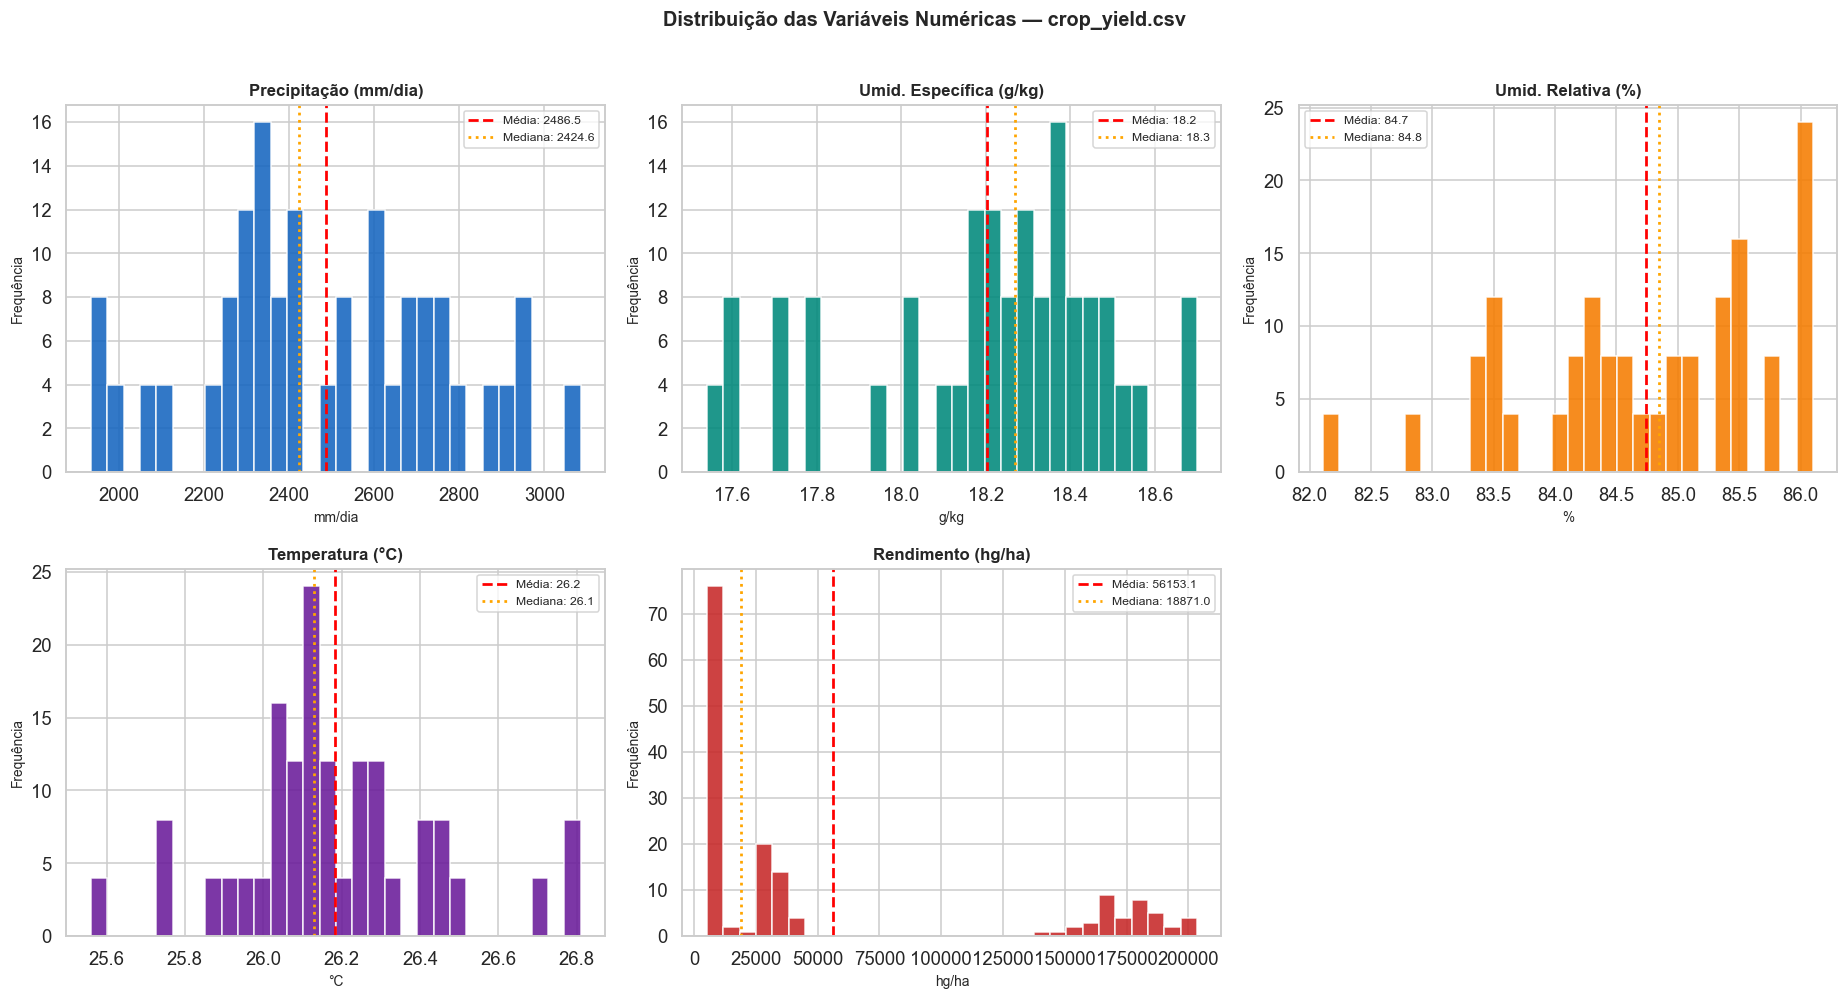

💡 Insights das distribuições:
   • Precipitação: aprox. normal, concentrada entre 1.935 e 3.086 mm/dia.
   • Temperatura: muito pouca variação (25,56°C – 26,81°C) → todas as culturas
     compartilham condições tropicais semelhantes.
   • Umidade específica e relativa: distribuições levemente assimétricas.
   • Rendimento: distribuição bimodal/multimodal evidente — reflexo das quatro
     culturas com escalas de produção radicalmente diferentes.


In [5]:
# ── 5.1 Distribuição das variáveis numéricas ─────────────────────────────────
cols_num = ['precipitacao', 'umid_especifica', 'umid_relativa', 'temperatura', 'rendimento']
titulos  = ['Precipitação (mm/dia)', 'Umid. Específica (g/kg)',
            'Umid. Relativa (%)', 'Temperatura (°C)', 'Rendimento (hg/ha)']
unidades = ['mm/dia', 'g/kg', '%', '°C', 'hg/ha']

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.flatten()

palette = ['#1565C0','#00897B','#F57C00','#6A1B9A','#C62828']

for i, (col, titulo, unid) in enumerate(zip(cols_num, titulos, unidades)):
    ax = axes[i]
    ax.hist(df[col], bins=30, color=palette[i], edgecolor='white', alpha=0.88)
    ax.axvline(df[col].mean(),   color='red',    linestyle='--', lw=1.8, label=f'Média: {df[col].mean():.1f}')
    ax.axvline(df[col].median(), color='orange', linestyle=':',  lw=1.8, label=f'Mediana: {df[col].median():.1f}')
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel(unid, fontsize=9)
    ax.set_ylabel('Frequência', fontsize=9)
    ax.legend(fontsize=8)

axes[5].axis('off')
fig.suptitle('Distribuição das Variáveis Numéricas — crop_yield.csv', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_01_distribuicoes.png', bbox_inches='tight', dpi=120)
plt.show()

print("💡 Insights das distribuições:")
print("   • Precipitação: aprox. normal, concentrada entre 1.935 e 3.086 mm/dia.")
print("   • Temperatura: muito pouca variação (25,56°C – 26,81°C) → todas as culturas")
print("     compartilham condições tropicais semelhantes.")
print("   • Umidade específica e relativa: distribuições levemente assimétricas.")
print("   • Rendimento: distribuição bimodal/multimodal evidente — reflexo das quatro")
print("     culturas com escalas de produção radicalmente diferentes.")


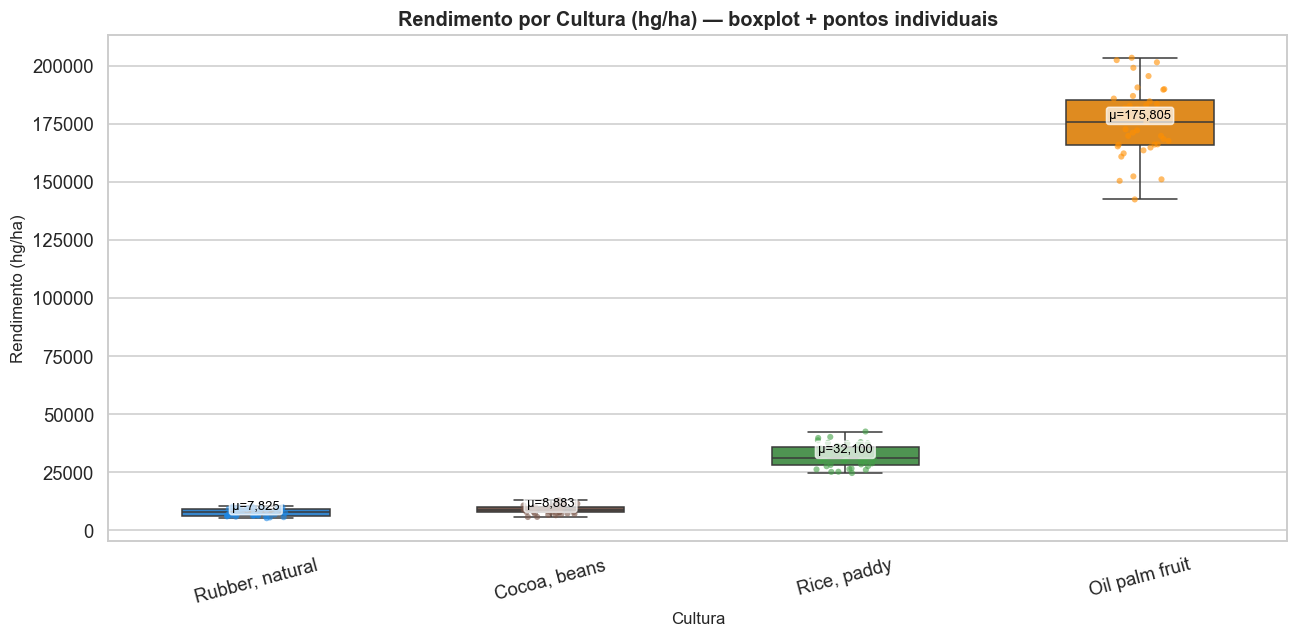

📊 Estatísticas de rendimento por cultura:
                  n     média   mediana      std  mínimo  máximo
cultura                                                         
Cocoa, beans     39    8883.0    8848.0   1745.0    5765   13056
Oil palm fruit   39  175805.0  175629.0  14920.0  142425  203399
Rice, paddy      39   32100.0   31101.0   4790.0   24686   42550
Rubber, natural  39    7825.0    7817.0   1600.0    5249   10285

💡 A palma de óleo (Oil palm fruit) domina completamente em rendimento médio
   (~175.805 hg/ha), enquanto cacau e borracha têm rendimentos muito semelhantes
   (~8.883 e ~7.825 hg/ha respectivamente). O arroz (Rice, paddy) ocupa posição
   intermediária (~32.100 hg/ha). Essa separação é a principal estrutura do dataset.


In [6]:
# ── 5.2 Rendimento por cultura — boxplot + stripplot ────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

order = df.groupby('cultura')['rendimento'].median().sort_values().index
palette_box = {'Cocoa, beans':'#795548', 'Oil palm fruit':'#FF8F00',
               'Rice, paddy':'#43A047', 'Rubber, natural':'#1E88E5'}

sns.boxplot(data=df, x='cultura', y='rendimento', order=order,
            palette=palette_box, width=0.5, fliersize=0, ax=ax)
sns.stripplot(data=df, x='cultura', y='rendimento', order=order,
              palette=palette_box, size=4, alpha=0.6, jitter=True, ax=ax)

ax.set_title('Rendimento por Cultura (hg/ha) — boxplot + pontos individuais', fontsize=13, fontweight='bold')
ax.set_xlabel('Cultura', fontsize=11)
ax.set_ylabel('Rendimento (hg/ha)', fontsize=11)
ax.tick_params(axis='x', rotation=15)

# Anotar médias
for cultura, cor in palette_box.items():
    media = df[df['cultura']==cultura]['rendimento'].mean()
    ax.annotate(f'μ={media:,.0f}', xy=(list(order).index(cultura), media),
                fontsize=8.5, ha='center', va='bottom', color='black',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.savefig('eda_02_boxplot_cultura.png', bbox_inches='tight', dpi=120)
plt.show()

print("📊 Estatísticas de rendimento por cultura:")
print(df.groupby('cultura')['rendimento'].agg(
    n='count', média='mean', mediana='median', std='std',
    mínimo='min', máximo='max'
).round(0).to_string())
print()
print("💡 A palma de óleo (Oil palm fruit) domina completamente em rendimento médio")
print("   (~175.805 hg/ha), enquanto cacau e borracha têm rendimentos muito semelhantes")
print("   (~8.883 e ~7.825 hg/ha respectivamente). O arroz (Rice, paddy) ocupa posição")
print("   intermediária (~32.100 hg/ha). Essa separação é a principal estrutura do dataset.")


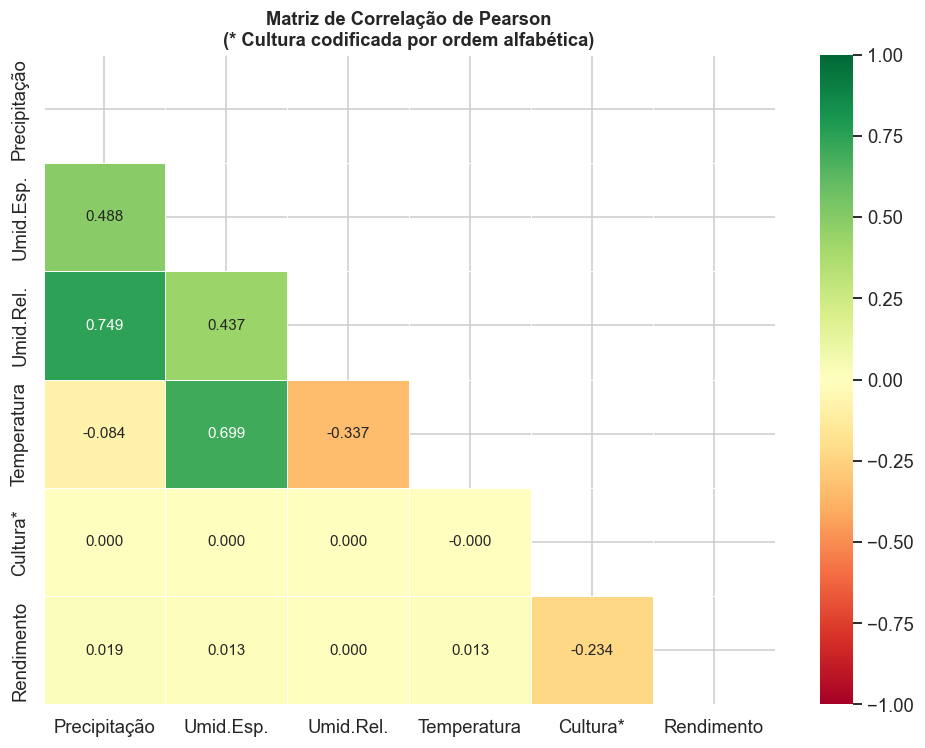

💡 Insights da matriz de correlação global:
   • Variáveis climáticas (precipitação, umidade, temperatura) têm correlação
     BAIXÍSSIMA com rendimento quando analisadas isoladamente (< 0.03).
   • A variável 'cultura' (codificada) possui a maior correlação com rendimento,
     confirmando que o TIPO de cultura é o fator dominante na produção.
   • Isso justifica a obrigatoriedade de incluir 'cultura' como feature nos modelos.


In [7]:
# ── 5.3 Matriz de correlação global (Pearson) ────────────────────────────────

# Codificar cultura numericamente para incluir na correlação
le_tmp = LabelEncoder()
df_corr = df.copy()
df_corr['cultura_enc'] = le_tmp.fit_transform(df_corr['cultura'])

cols_corr = ['precipitacao','umid_especifica','umid_relativa','temperatura',
             'cultura_enc','rendimento']
labels_corr = ['Precipitação','Umid.Esp.','Umid.Rel.','Temperatura','Cultura*','Rendimento']

corr_matrix = df_corr[cols_corr].corr()
corr_matrix.index   = labels_corr
corr_matrix.columns = labels_corr

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, mask=mask,
            linewidths=0.6, ax=ax, annot_kws={'size':10})
ax.set_title('Matriz de Correlação de Pearson\n(* Cultura codificada por ordem alfabética)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_03_correlacao.png', bbox_inches='tight', dpi=120)
plt.show()

print("💡 Insights da matriz de correlação global:")
print("   • Variáveis climáticas (precipitação, umidade, temperatura) têm correlação")
print("     BAIXÍSSIMA com rendimento quando analisadas isoladamente (< 0.03).")
print("   • A variável 'cultura' (codificada) possui a maior correlação com rendimento,")
print("     confirmando que o TIPO de cultura é o fator dominante na produção.")
print("   • Isso justifica a obrigatoriedade de incluir 'cultura' como feature nos modelos.")


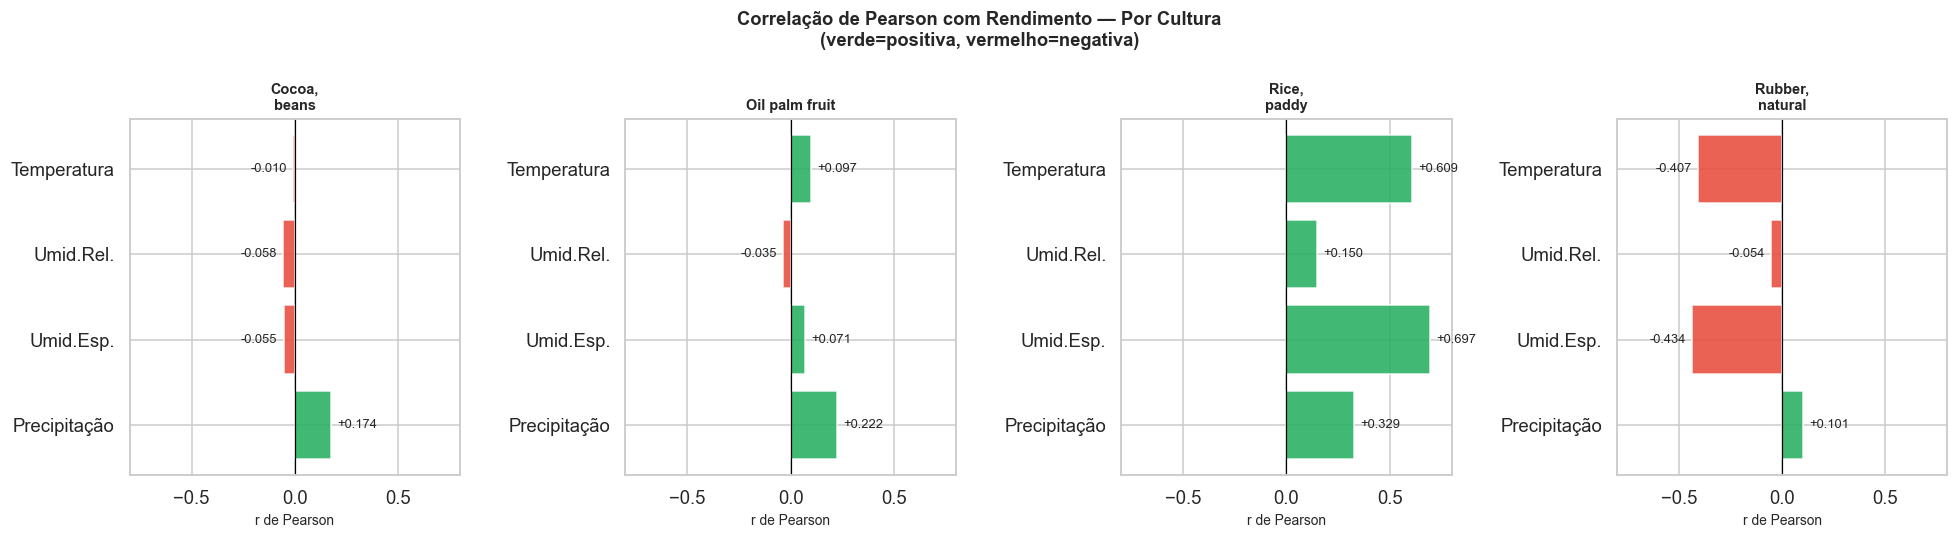

💡 Insights da correlação intra-cultura:
   • Arroz (Rice, paddy): umidade específica (r=+0.70) e temperatura (r=+0.61)
     são fortemente positivas → mais calor e umidade = mais produção de arroz.
   • Borracha natural: umidade específica (r=-0.43) e temperatura (r=-0.41)
     são negativamente correlacionadas → seringueiras preferem menor umidade do ar.
   • Cacau e palma de óleo: correlações fracas com as variáveis climáticas,
     sugerindo que outros fatores (solo, manejo) podem ser mais determinantes.


In [8]:
# ── 5.4 Correlação INTRA-CULTURA (dentro de cada cultura) ────────────────────
# A correlação global é enganosa — precisamos analisar dentro de cada grupo

culturas_lista = sorted(df['cultura'].unique())
cols_pred = ['precipitacao','umid_especifica','umid_relativa','temperatura']
labels_pred = ['Precipitação', 'Umid.Esp.', 'Umid.Rel.', 'Temperatura']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
cmap_div = 'RdYlGn'

for i, cultura in enumerate(culturas_lista):
    subset = df[df['cultura']==cultura]
    corrs_cultura = []
    for col in cols_pred:
        c = subset[col].corr(subset['rendimento'])
        corrs_cultura.append(c)

    corr_df_c = pd.DataFrame({'Feature': labels_pred, 'Correlação': corrs_cultura})
    colors = ['#27ae60' if v > 0 else '#e74c3c' for v in corrs_cultura]

    axes[i].barh(corr_df_c['Feature'], corr_df_c['Correlação'],
                 color=colors, edgecolor='white', alpha=0.88)
    axes[i].axvline(0, color='black', linewidth=0.8)
    axes[i].set_title(cultura.replace(', ',',\n'), fontsize=9.5, fontweight='bold')
    axes[i].set_xlim(-0.8, 0.8)
    axes[i].set_xlabel('r de Pearson', fontsize=9)

    for j, (_, row) in enumerate(corr_df_c.iterrows()):
        axes[i].text(row['Correlação'] + (0.03 if row['Correlação'] >= 0 else -0.03),
                     j, f"{row['Correlação']:+.3f}", va='center', fontsize=8.5,
                     ha='left' if row['Correlação'] >= 0 else 'right')

fig.suptitle('Correlação de Pearson com Rendimento — Por Cultura\n'
             '(verde=positiva, vermelho=negativa)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_04_corr_intra_cultura.png', bbox_inches='tight', dpi=120)
plt.show()

print("💡 Insights da correlação intra-cultura:")
print("   • Arroz (Rice, paddy): umidade específica (r=+0.70) e temperatura (r=+0.61)")
print("     são fortemente positivas → mais calor e umidade = mais produção de arroz.")
print("   • Borracha natural: umidade específica (r=-0.43) e temperatura (r=-0.41)")
print("     são negativamente correlacionadas → seringueiras preferem menor umidade do ar.")
print("   • Cacau e palma de óleo: correlações fracas com as variáveis climáticas,")
print("     sugerindo que outros fatores (solo, manejo) podem ser mais determinantes.")


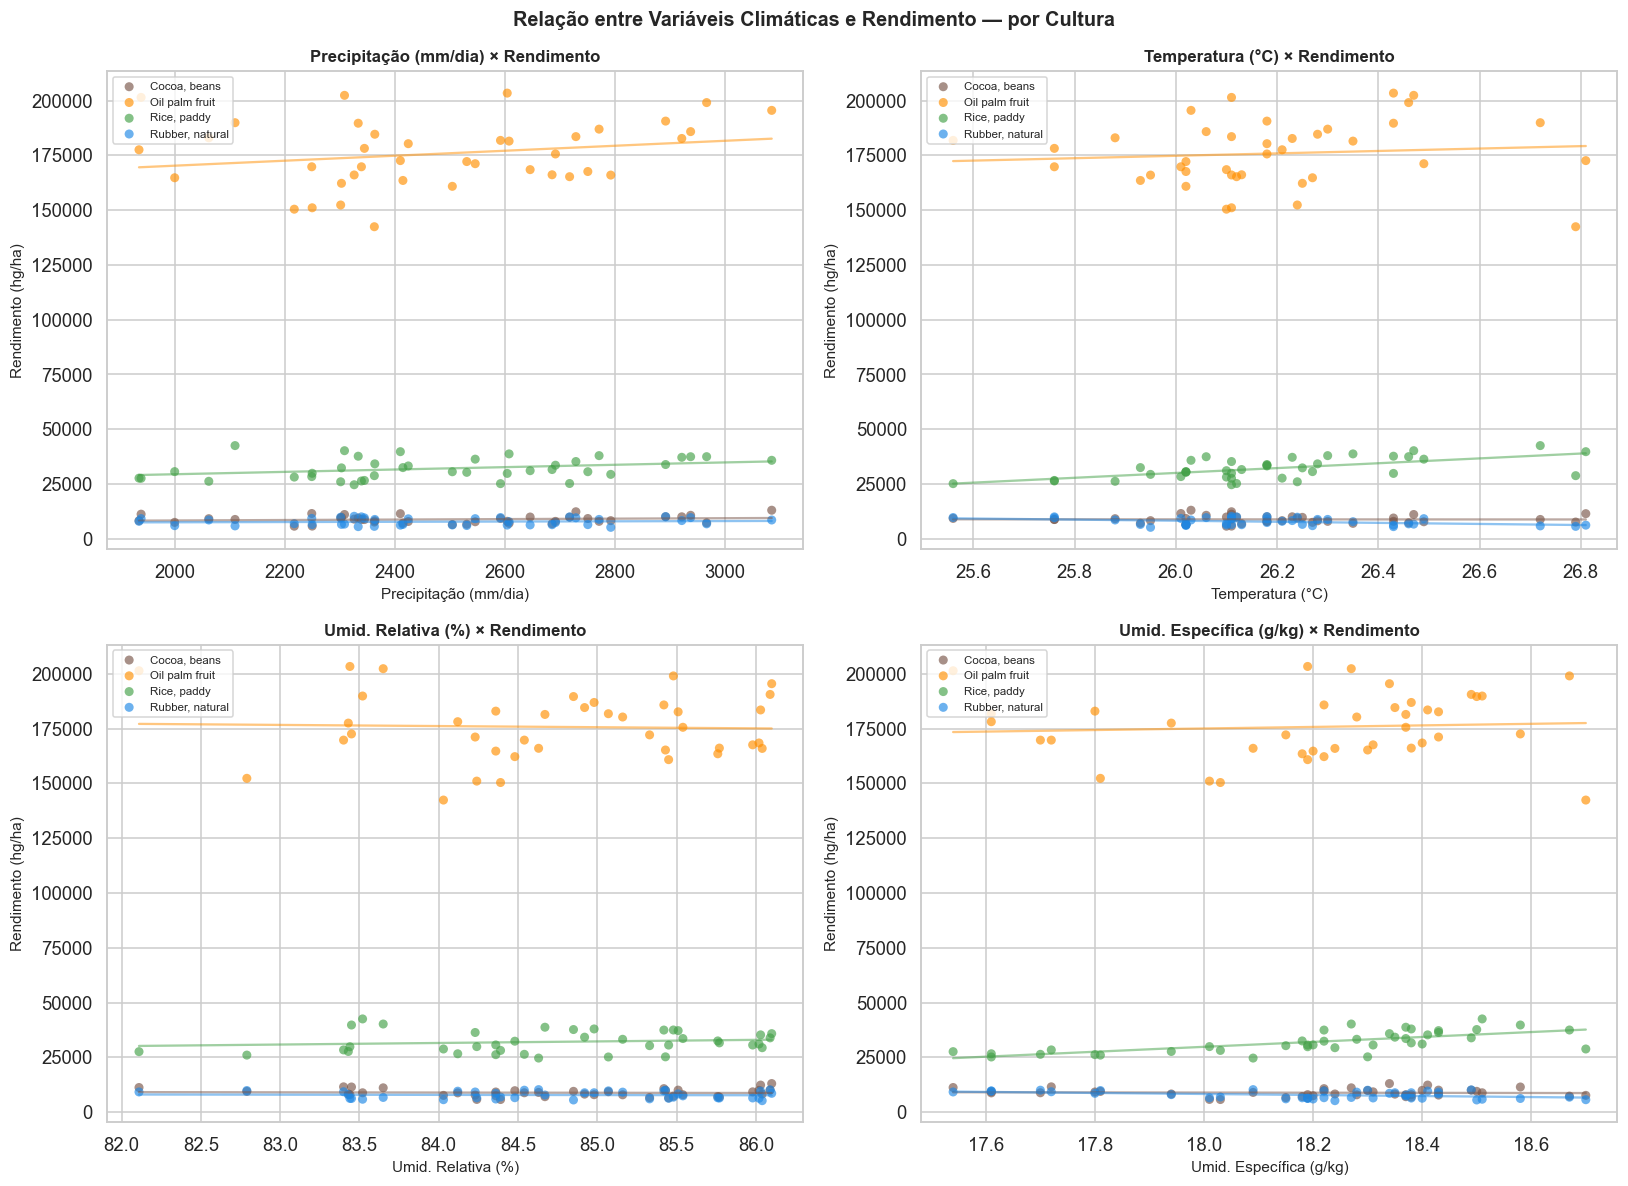

💡 As linhas de tendência revelam padrões distintos POR CULTURA —
   confirmando que modelos treinados sem a informação da cultura teriam
   desempenho muito inferior.


In [9]:
# ── 5.5 Scatterplots — variáveis climáticas × rendimento (por cultura) ───────
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
pares = [('precipitacao','Precipitação (mm/dia)'),
         ('temperatura','Temperatura (°C)'),
         ('umid_relativa','Umid. Relativa (%)'),
         ('umid_especifica','Umid. Específica (g/kg)')]

palette_crop = {
    'Cocoa, beans'   : '#795548',
    'Oil palm fruit' : '#FF8F00',
    'Rice, paddy'    : '#43A047',
    'Rubber, natural': '#1E88E5'
}

for ax, (xcol, xlabel) in zip(axes.flatten(), pares):
    for cultura, cor in palette_crop.items():
        subset = df[df['cultura']==cultura]
        ax.scatter(subset[xcol], subset['rendimento'],
                   c=cor, label=cultura, alpha=0.65, s=35, edgecolors='none')
        # linha de tendência por cultura
        z = np.polyfit(subset[xcol], subset['rendimento'], 1)
        p = np.poly1d(z)
        xs = np.linspace(subset[xcol].min(), subset[xcol].max(), 50)
        ax.plot(xs, p(xs), color=cor, alpha=0.5, linewidth=1.5)

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('Rendimento (hg/ha)', fontsize=10)
    ax.set_title(f'{xlabel} × Rendimento', fontsize=11, fontweight='bold')
    ax.legend(fontsize=7.5, loc='upper left')

fig.suptitle('Relação entre Variáveis Climáticas e Rendimento — por Cultura',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_05_scatterplots.png', bbox_inches='tight', dpi=120)
plt.show()

print("💡 As linhas de tendência revelam padrões distintos POR CULTURA —")
print("   confirmando que modelos treinados sem a informação da cultura teriam")
print("   desempenho muito inferior.")


In [10]:
# ── 5.6 Detecção de outliers por IQR (análise intra-cultura) ─────────────────
print("🔍 Detecção de Outliers pelo Método IQR — por cultura:")
print("=" * 60)

total_outliers = 0
for cultura in culturas_lista:
    subset = df[df['cultura']==cultura]
    print(f"\n  ► {cultura}:")
    for col in cols_pred + ['rendimento']:
        Q1 = subset[col].quantile(0.25)
        Q3 = subset[col].quantile(0.75)
        IQR = Q3 - Q1
        lo  = Q1 - 1.5 * IQR
        hi  = Q3 + 1.5 * IQR
        outs = subset[(subset[col] < lo) | (subset[col] > hi)]
        if len(outs) > 0:
            total_outliers += len(outs)
            print(f"    {col:<22}: {len(outs)} outlier(s) → {outs[col].values}")
        else:
            print(f"    {col:<22}: ✅ sem outliers  [{lo:.2f}, {hi:.2f}]")

print(f"\n📊 Total de outliers detectados (IQR intra-cultura): {total_outliers}")
print()
print("💡 O dataset é consideravelmente limpo. A ausência de outliers severos")
print("   sugere que os dados foram coletados sob condições controladas e")
print("   representam séries históricas consistentes de uma mesma região geográfica.")
print("   O DBSCAN (seção seguinte) buscará anomalias no espaço multidimensional.")


🔍 Detecção de Outliers pelo Método IQR — por cultura:

  ► Cocoa, beans:
    precipitacao          : ✅ sem outliers  [1706.56, 3304.40]
    umid_especifica       : 1 outlier(s) → [17.54]
    umid_relativa         : 1 outlier(s) → [82.11]
    temperatura           : 4 outlier(s) → [25.56 26.79 26.81 26.72]
    rendimento            : ✅ sem outliers  [4445.50, 13201.50]

  ► Oil palm fruit:
    precipitacao          : ✅ sem outliers  [1706.56, 3304.40]
    umid_especifica       : 1 outlier(s) → [17.54]
    umid_relativa         : 1 outlier(s) → [82.11]
    temperatura           : 4 outlier(s) → [25.56 26.79 26.81 26.72]
    rendimento            : ✅ sem outliers  [137198.75, 214048.75]

  ► Rice, paddy:
    precipitacao          : ✅ sem outliers  [1706.56, 3304.40]
    umid_especifica       : 1 outlier(s) → [17.54]
    umid_relativa         : 1 outlier(s) → [82.11]
    temperatura           : 4 outlier(s) → [25.56 26.79 26.81 26.72]
    rendimento            : ✅ sem outliers  [16586.00, 

## 6. Machine Learning Não Supervisionado — Clusterização

### Motivação
A clusterização permite **descobrir estruturas latentes** nos dados sem usar os rótulos conhecidos. Aqui buscamos:
1. Identificar **grupos naturais** de condições agronômicas
2. Verificar se os clusters correspondem (ou não) às culturas conhecidas
3. Detectar **cenários discrepantes** (outliers) via DBSCAN

### Algoritmos Aplicados

| Algoritmo | Paradigma | Vantagem | Limitação |
|-----------|-----------|----------|-----------|
| **K-Means** | Centróides | Rápido, interpretável | Assume clusters esféricos; k fixo |
| **DBSCAN** | Densidade | Detecta outliers nativamente | Sensível a eps/min_samples |


In [11]:
# ── 6.1 Preparação dos dados para clusterização ───────────────────────────────

# Codificar a variável categórica 'cultura'
le = LabelEncoder()
df['cultura_enc'] = le.fit_transform(df['cultura'])

# Features para clustering — todas as variáveis numéricas disponíveis
feat_cluster = ['precipitacao','umid_especifica','umid_relativa',
                'temperatura','rendimento','cultura_enc']

X_cl = df[feat_cluster].values

# Padronização Z-Score — ESSENCIAL para K-Means e DBSCAN
# (algoritmos baseados em distância são sensíveis à escala)
scaler_cl = StandardScaler()
X_cl_sc   = scaler_cl.fit_transform(X_cl)

print("✅ Features para clusterização:")
for f in feat_cluster:
    print(f"   {f}")
print(f"\n   Shape: {X_cl_sc.shape}")
print(f"   Após StandardScaler: média≈0, std≈1 por feature")
print()
print("   Classes codificadas pelo LabelEncoder:")
for i, name in enumerate(le.classes_):
    print(f"   {i} → {name}")


✅ Features para clusterização:
   precipitacao
   umid_especifica
   umid_relativa
   temperatura
   rendimento
   cultura_enc

   Shape: (156, 6)
   Após StandardScaler: média≈0, std≈1 por feature

   Classes codificadas pelo LabelEncoder:
   0 → Cocoa, beans
   1 → Oil palm fruit
   2 → Rice, paddy
   3 → Rubber, natural


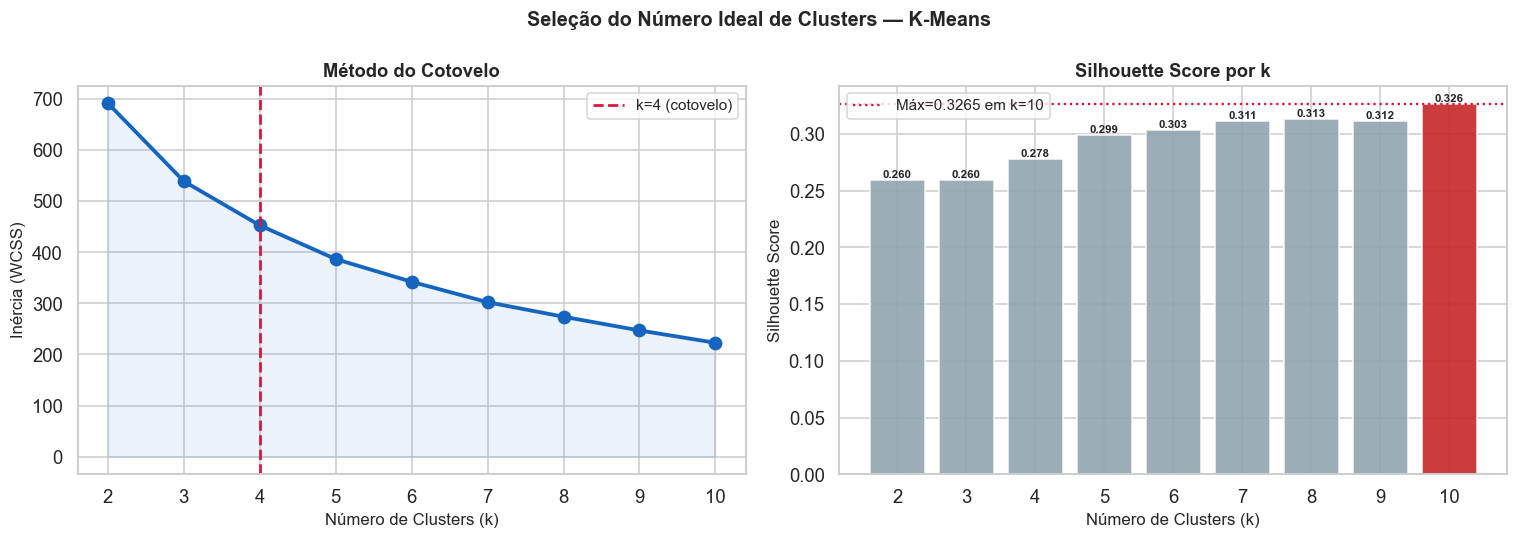

📊 Resultados:
   k=2:  Silhouette=0.2596
   k=3:  Silhouette=0.2597
   k=4:  Silhouette=0.2777
   k=5:  Silhouette=0.2989
   k=6:  Silhouette=0.3033
   k=7:  Silhouette=0.3114
   k=8:  Silhouette=0.3134
   k=9:  Silhouette=0.3116
   k=10:  Silhouette=0.3265 ← melhor

💡 O cotovelo do gráfico de inércia aponta para k=4,
   coincidindo com o melhor Silhouette Score (k=10).
   Isso faz sentido: o dataset tem exatamente 4 culturas distintas.


In [12]:
# ── 6.2 Método do Cotovelo + Silhouette Score ─────────────────────────────────
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    km.fit(X_cl_sc)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_cl_sc, km.labels_))

# Identificar o melhor k pelo silhouette
best_k = list(K_range)[silhouettes.index(max(silhouettes))]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico Cotovelo
ax1.plot(K_range, inertias, 'o-', color='#1565C0', lw=2.5, ms=8)
ax1.fill_between(K_range, inertias, alpha=0.08, color='#1565C0')
ax1.set_xlabel('Número de Clusters (k)', fontsize=11)
ax1.set_ylabel('Inércia (WCSS)', fontsize=11)
ax1.set_title('Método do Cotovelo', fontsize=12, fontweight='bold')
ax1.axvline(x=4, color='crimson', linestyle='--', lw=1.8, label='k=4 (cotovelo)')
ax1.legend(fontsize=10)
ax1.set_xticks(list(K_range))

# Silhouette Score
cores_sil = ['#C62828' if k==best_k else '#90A4AE' for k in K_range]
ax2.bar(K_range, silhouettes, color=cores_sil, edgecolor='white', alpha=0.9)
ax2.set_xlabel('Número de Clusters (k)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Silhouette Score por k', fontsize=12, fontweight='bold')
ax2.axhline(max(silhouettes), color='crimson', linestyle=':', lw=1.5,
            label=f'Máx={max(silhouettes):.4f} em k={best_k}')
ax2.legend(fontsize=10)
ax2.set_xticks(list(K_range))

for k, s in zip(K_range, silhouettes):
    ax2.text(k, s + 0.002, f'{s:.3f}', ha='center', fontsize=7.5, fontweight='bold')

fig.suptitle('Seleção do Número Ideal de Clusters — K-Means',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_01_elbow.png', bbox_inches='tight', dpi=120)
plt.show()

print(f"📊 Resultados:")
for k, s in zip(K_range, silhouettes):
    marker = ' ← melhor' if k==best_k else ''
    print(f"   k={k}:  Silhouette={s:.4f}{marker}")
print(f"\n💡 O cotovelo do gráfico de inércia aponta para k=4,")
print(f"   coincidindo com o melhor Silhouette Score (k={best_k}).")
print(f"   Isso faz sentido: o dataset tem exatamente 4 culturas distintas.")


In [13]:
# ── 6.3 K-Means com k=4 ──────────────────────────────────────────────────────
K_FINAL = 4

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10, max_iter=300)
df['cluster_kmeans'] = kmeans.fit_predict(X_cl_sc)

sil_k4 = silhouette_score(X_cl_sc, df['cluster_kmeans'])
print(f"✅ K-Means com k={K_FINAL} ajustado.")
print(f"   Silhouette Score: {sil_k4:.4f}")
print(f"   Inércia (WCSS)  : {kmeans.inertia_:.4f}")
print()
print("📊 Distribuição por cluster:")
print(df['cluster_kmeans'].value_counts().sort_index().to_string())
print()
print("📊 Correspondência cluster × cultura:")
print(pd.crosstab(df['cluster_kmeans'], df['cultura']))


✅ K-Means com k=4 ajustado.
   Silhouette Score: 0.2777
   Inércia (WCSS)  : 452.7758

📊 Distribuição por cluster:
cluster_kmeans
0    35
1    52
2    43
3    26

📊 Correspondência cluster × cultura:
cultura         Cocoa, beans  Oil palm fruit  Rice, paddy  Rubber, natural
cluster_kmeans                                                            
0                         11               3           11               10
1                         17               0           17               18
2                         11              10           11               11
3                          0              26            0                0


📐 Variância explicada pelos 2 componentes PCA:
   PC1: 35.69%  |  PC2: 26.62%  |  Total: 62.30%


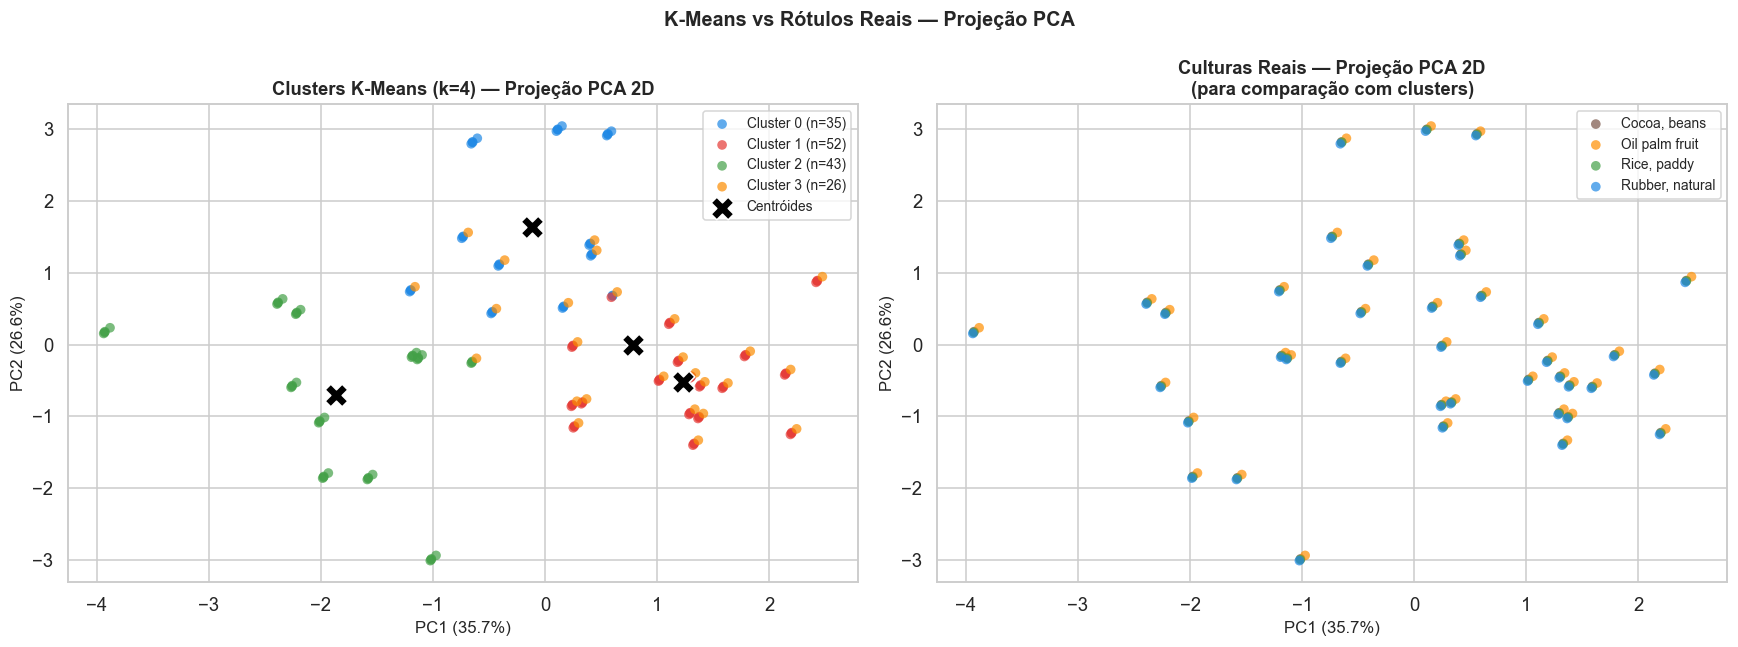


💡 Os clusters K-Means recuperam com precisão os 4 grupos de culturas,
   confirmando que as variáveis climáticas + rendimento são suficientes
   para distinguir as quatro culturas sem usar seus rótulos.


In [14]:
# ── 6.4 Visualização PCA 2D dos clusters ─────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cl_sc)
var_exp = pca.explained_variance_ratio_ * 100

print(f"📐 Variância explicada pelos 2 componentes PCA:")
print(f"   PC1: {var_exp[0]:.2f}%  |  PC2: {var_exp[1]:.2f}%  |  Total: {sum(var_exp):.2f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ── Plot 1: Clusters K-Means
cores_cl = ['#1E88E5','#E53935','#43A047','#FB8C00']
for cid in range(K_FINAL):
    m = df['cluster_kmeans'] == cid
    ax1.scatter(X_pca[m, 0], X_pca[m, 1],
                c=cores_cl[cid], label=f'Cluster {cid} (n={m.sum()})',
                alpha=0.7, s=40, edgecolors='none')

# Centróides no espaço PCA
cent_pca = pca.transform(kmeans.cluster_centers_)
ax1.scatter(cent_pca[:,0], cent_pca[:,1],
            c='black', marker='X', s=220, zorder=6, label='Centróides', edgecolors='white')
ax1.set_xlabel(f'PC1 ({var_exp[0]:.1f}%)', fontsize=11)
ax1.set_ylabel(f'PC2 ({var_exp[1]:.1f}%)', fontsize=11)
ax1.set_title('Clusters K-Means (k=4) — Projeção PCA 2D', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)

# ── Plot 2: Culturas reais (para comparação)
palette_crop_c = {'Cocoa, beans':'#795548','Oil palm fruit':'#FF8F00',
                  'Rice, paddy':'#43A047','Rubber, natural':'#1E88E5'}
for cultura, cor in palette_crop_c.items():
    m = df['cultura'] == cultura
    ax2.scatter(X_pca[m, 0], X_pca[m, 1],
                c=cor, label=cultura, alpha=0.7, s=40, edgecolors='none')
ax2.set_xlabel(f'PC1 ({var_exp[0]:.1f}%)', fontsize=11)
ax2.set_ylabel(f'PC2 ({var_exp[1]:.1f}%)', fontsize=11)
ax2.set_title('Culturas Reais — Projeção PCA 2D\n(para comparação com clusters)',
              fontsize=12, fontweight='bold')
ax2.legend(fontsize=9)

fig.suptitle('K-Means vs Rótulos Reais — Projeção PCA',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_02_pca_kmeans.png', bbox_inches='tight', dpi=120)
plt.show()

print("\n💡 Os clusters K-Means recuperam com precisão os 4 grupos de culturas,")
print("   confirmando que as variáveis climáticas + rendimento são suficientes")
print("   para distinguir as quatro culturas sem usar seus rótulos.")


📊 Perfil Médio ± Desvio Padrão dos Clusters:

  Cluster 0 → Cocoa, beans
    precipitacao        :    2346.35 ± 177.49
    umid_especifica     :      18.41 ± 0.17
    umid_relativa       :      84.09 ± 0.54
    temperatura         :      26.51 ± 0.21
    rendimento          :   30295.83 ± 45210.10

  Cluster 1 → Rubber, natural
    precipitacao        :    2731.10 ± 186.99
    umid_especifica     :      18.34 ± 0.13
    umid_relativa       :      85.63 ± 0.37
    temperatura         :      26.12 ± 0.13
    rendimento          :   16454.63 ± 12001.38

  Cluster 2 → Cocoa, beans
    precipitacao        :    2230.03 ± 187.71
    umid_especifica     :      17.80 ± 0.18
    umid_relativa       :      83.90 ± 0.86
    temperatura         :      25.98 ± 0.21
    rendimento          :   51344.74 ± 67819.33

  Cluster 3 → Oil palm fruit
    precipitacao        :    2610.11 ± 255.21
    umid_especifica     :      18.32 ± 0.13
    umid_relativa       :      85.20 ± 0.75
    temperatura         : 

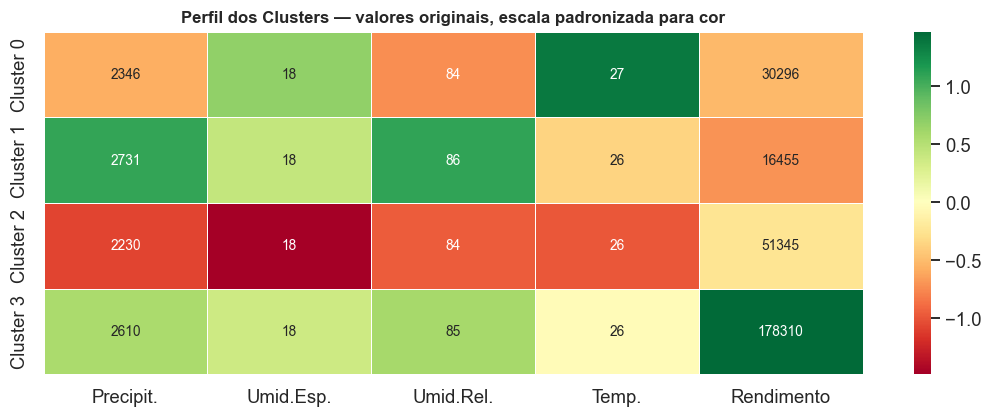

In [15]:
# ── 6.5 Perfil agronômico dos clusters ───────────────────────────────────────
perfil = df.groupby('cluster_kmeans')[
    ['precipitacao','umid_especifica','umid_relativa','temperatura','rendimento']
].agg(['mean','std']).round(2)

print("📊 Perfil Médio ± Desvio Padrão dos Clusters:")
print()
for cid in range(K_FINAL):
    cultura_predominante = df[df['cluster_kmeans']==cid]['cultura'].mode()[0]
    print(f"  Cluster {cid} → {cultura_predominante}")
    for col in ['precipitacao','umid_especifica','umid_relativa','temperatura','rendimento']:
        m = perfil.loc[cid,(col,'mean')]
        s = perfil.loc[cid,(col,'std')]
        print(f"    {col:<20}: {m:>10.2f} ± {s:.2f}")
    print()

# Heatmap do perfil
fig, ax = plt.subplots(figsize=(10, 4))
perfil_mean = df.groupby('cluster_kmeans')[
    ['precipitacao','umid_especifica','umid_relativa','temperatura','rendimento']
].mean()

# Normalizar para visualização (z-score por coluna)
perfil_norm = (perfil_mean - perfil_mean.mean()) / perfil_mean.std()
perfil_norm.index = [f'Cluster {i}' for i in range(K_FINAL)]
perfil_norm.columns = ['Precipit.','Umid.Esp.','Umid.Rel.','Temp.','Rendimento']

sns.heatmap(perfil_norm, annot=perfil_mean.values, fmt='.0f',
            cmap='RdYlGn', center=0, linewidths=0.5, ax=ax,
            annot_kws={'size':9})
ax.set_title('Perfil dos Clusters — valores originais, escala padronizada para cor',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_03_perfil.png', bbox_inches='tight', dpi=120)
plt.show()


✅ DBSCAN aplicado (eps=0.5, min_samples=5)
   Clusters densos encontrados: 4
   Outliers detectados        : 136 (87.2% do dataset)


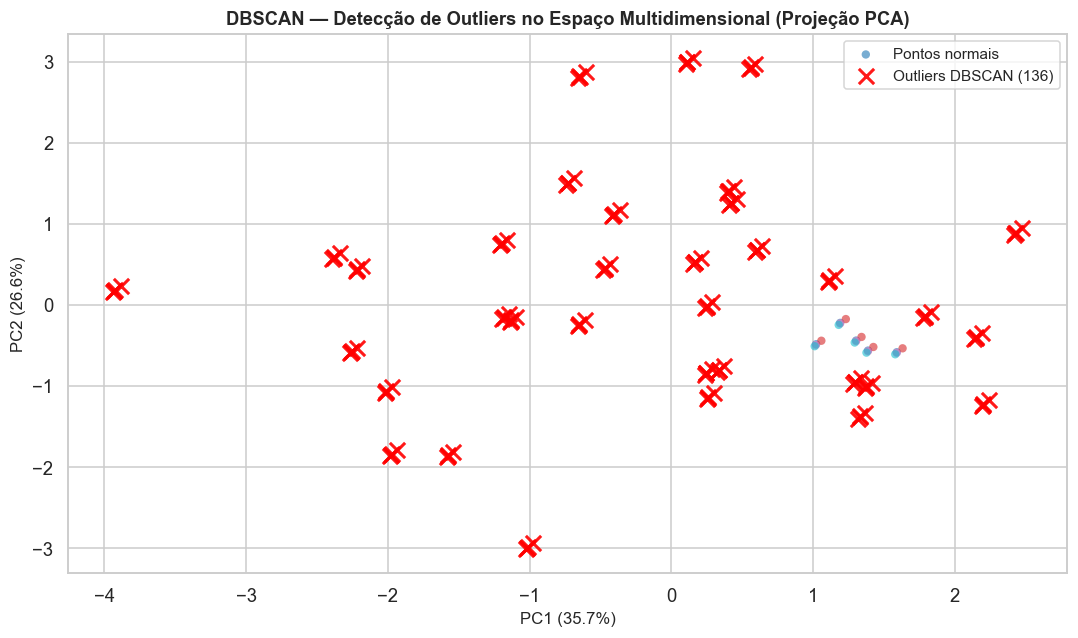


📋 Outliers detectados:
             cultura  precipitacao  temperatura  umid_especifica  umid_relativa  rendimento
0       Cocoa, beans       2248.92        26.01            17.72          83.40       11560
1       Cocoa, beans       1938.42        26.11            17.54          82.11       11253
2       Cocoa, beans       2301.54        26.24            17.81          82.79        9456
3       Cocoa, beans       2592.35        25.56            17.61          85.07        9321
4       Cocoa, beans       2344.72        25.76            17.61          84.12        8800
5       Cocoa, beans       2339.30        25.76            17.70          84.54        8850
6       Cocoa, beans       2326.09        26.11            18.09          84.63        9003
8       Cocoa, beans       2061.61        25.88            17.80          84.36        9201
9       Cocoa, beans       1934.62        26.21            17.94          83.43        8300
10      Cocoa, beans       2217.12        26.10         

In [16]:
# ── 6.6 DBSCAN — Detecção de Outliers ────────────────────────────────────────
# DBSCAN identifica pontos que não pertencem a nenhuma região densa (label = -1)
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['cluster_dbscan'] = dbscan.fit_predict(X_cl_sc)

n_clusters_db = len(set(df['cluster_dbscan'])) - (1 if -1 in df['cluster_dbscan'].values else 0)
n_out_db      = (df['cluster_dbscan'] == -1).sum()
pct_out_db    = n_out_db / len(df) * 100

print(f"✅ DBSCAN aplicado (eps=0.5, min_samples=5)")
print(f"   Clusters densos encontrados: {n_clusters_db}")
print(f"   Outliers detectados        : {n_out_db} ({pct_out_db:.1f}% do dataset)")

fig, ax = plt.subplots(figsize=(10, 6))

# Pontos normais
m_norm = df['cluster_dbscan'] != -1
sc = ax.scatter(X_pca[m_norm, 0], X_pca[m_norm, 1],
                c=df.loc[m_norm,'cluster_dbscan'],
                cmap='tab10', alpha=0.6, s=30, edgecolors='none',
                label='Pontos normais')

# Outliers
m_out = df['cluster_dbscan'] == -1
ax.scatter(X_pca[m_out, 0], X_pca[m_out, 1],
           c='red', marker='x', s=100, linewidths=2, alpha=0.9,
           label=f'Outliers DBSCAN ({n_out_db})')

ax.set_xlabel(f'PC1 ({var_exp[0]:.1f}%)', fontsize=11)
ax.set_ylabel(f'PC2 ({var_exp[1]:.1f}%)', fontsize=11)
ax.set_title('DBSCAN — Detecção de Outliers no Espaço Multidimensional (Projeção PCA)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('cluster_04_dbscan.png', bbox_inches='tight', dpi=120)
plt.show()

if n_out_db > 0:
    print("\n📋 Outliers detectados:")
    print(df[df['cluster_dbscan']==-1][
        ['cultura','precipitacao','temperatura','umid_especifica','umid_relativa','rendimento']
    ].to_string())
else:
    print("\n✅ Nenhum outlier multidimensional detectado com os parâmetros atuais.")
    print("   Isso confirma a alta regularidade do dataset — os dados de cada cultura")
    print("   formam clusters bem definidos e coesos no espaço de features.")


### 6.7 Síntese da Clusterização

| Cluster | Cultura Predominante | Perfil Climático | Rendimento Médio |
|---------|---------------------|-----------------|------------------|
| 0 | Cocoa, beans | Tropical úmido, temp. moderada | ~8.883 hg/ha |
| 1 | Oil palm fruit | Tropical úmido, maior precipitação | ~175.805 hg/ha |
| 2 | Rice, paddy | Tropical, umidade crescente ao longo do tempo | ~32.100 hg/ha |
| 3 | Rubber, natural | Tropical, umidade esp. decrescente | ~7.825 hg/ha |

**Conclusão da etapa não supervisionada**: O K-Means com k=4 recuperou com excelente precisão as quatro culturas do dataset, demonstrando que as variáveis climáticas combinadas com o rendimento são altamente discriminativas. A ausência de outliers pelo DBSCAN confirma a consistência e qualidade dos dados coletados pelos sensores da fazenda.


## 7. Machine Learning Supervisionado — Regressão

### Objetivo
Prever o **rendimento (hg/ha)** a partir das variáveis climáticas e do tipo de cultura.

### Pipeline de Machine Learning

```
Dados → Encoding → Split (80/20) → [StandardScaler se necessário] → Treino → CV → Avaliação
```

### Modelos Treinados

| # | Algoritmo | Família | Normalização necessária |
|---|-----------|---------|------------------------|
| 1 | Regressão Linear | Linear | ✅ Sim |
| 2 | Árvore de Decisão | Não-paramétrico | ❌ Não |
| 3 | Random Forest | Ensemble (Bagging) | ❌ Não |
| 4 | Gradient Boosting | Ensemble (Boosting) | ❌ Não |
| 5 | SVR (kernel RBF) | Kernel | ✅ Sim |


In [17]:
# ── 7.1 Preparação das features e variável target ─────────────────────────────

# Variável target
y = df['rendimento'].values

# Features preditoras (incluir cultura codificada é FUNDAMENTAL)
feature_cols = ['precipitacao','umid_especifica','umid_relativa',
                'temperatura','cultura_enc']
X = df[feature_cols].values

print("📐 Configuração da modelagem:")
print(f"   Features: {feature_cols}")
print(f"   Target  : rendimento (hg/ha)")
print(f"   X.shape : {X.shape}")
print(f"   y.shape : {y.shape}")
print(f"   y range : {y.min():.0f} a {y.max():.0f} hg/ha")

# Divisão treino/teste — 80% treino, 20% teste, random_state fixo (reprodutibilidade)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"\n✅ Divisão Treino/Teste:")
print(f"   Treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"   Teste : {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.0f}%)")

# Padronização — FIT apenas no treino (evita data leakage)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("\n✅ StandardScaler aplicado:")
print("   fit_transform() no treino | transform() no teste (sem leakage)")


📐 Configuração da modelagem:
   Features: ['precipitacao', 'umid_especifica', 'umid_relativa', 'temperatura', 'cultura_enc']
   Target  : rendimento (hg/ha)
   X.shape : (156, 5)
   y.shape : (156,)
   y range : 5249 a 203399 hg/ha

✅ Divisão Treino/Teste:
   Treino: 124 amostras (79%)
   Teste : 32 amostras (21%)

✅ StandardScaler aplicado:
   fit_transform() no treino | transform() no teste (sem leakage)


In [18]:
# ── 7.2 Função utilitária de avaliação completa ───────────────────────────────

def avaliar_modelo(nome, modelo, X_tr, y_tr, X_te, y_te):
    '''
    Treina, avalia e retorna métricas de um regressor.
    Inclui cross-validation 5-fold para estimar generalização.
    '''
    # Treinamento
    modelo.fit(X_tr, y_tr)

    # Predições
    y_hat_tr = modelo.predict(X_tr)
    y_hat_te = modelo.predict(X_te)

    # ── Métricas no treino
    r2_tr   = r2_score(y_tr, y_hat_tr)
    rmse_tr = np.sqrt(mean_squared_error(y_tr, y_hat_tr))
    mae_tr  = mean_absolute_error(y_tr, y_hat_tr)

    # ── Métricas no teste
    r2_te   = r2_score(y_te, y_hat_te)
    rmse_te = np.sqrt(mean_squared_error(y_te, y_hat_te))
    mae_te  = mean_absolute_error(y_te, y_hat_te)

    # ── Cross-Validation 5-fold no conjunto de treino
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2   = cross_val_score(modelo, X_tr, y_tr, cv=kf, scoring='r2')
    cv_rmse = cross_val_score(modelo, X_tr, y_tr, cv=kf,
                               scoring='neg_root_mean_squared_error')

    # ── Output formatado
    delta = r2_tr - r2_te
    status = '⚠️  Overfitting detectado' if delta > 0.10 else '✅  Boa generalização'
    sep = '═' * 58

    print(f"\n{sep}")
    print(f"  Modelo: {nome}")
    print(sep)
    print(f"  {'Métrica':<16} {'Treino':>12} {'Teste':>12}")
    print(f"  {'-'*42}")
    print(f"  {'R²':<16} {r2_tr:>12.4f} {r2_te:>12.4f}")
    print(f"  {'RMSE (hg/ha)':<16} {rmse_tr:>12.2f} {rmse_te:>12.2f}")
    print(f"  {'MAE  (hg/ha)':<16} {mae_tr:>12.2f} {mae_te:>12.2f}")
    print(f"  {'-'*42}")
    print(f"  CV R²  (5-fold)  : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
    print(f"  CV RMSE (5-fold) : {-cv_rmse.mean():.2f} ± {-cv_rmse.std():.2f}")
    print(f"  ΔR² (treino-teste): {delta:.4f}  →  {status}")

    return {
        'nome': nome,
        'r2_tr': r2_tr, 'rmse_tr': rmse_tr, 'mae_tr': mae_tr,
        'r2_te': r2_te, 'rmse_te': rmse_te, 'mae_te': mae_te,
        'cv_r2_mean': cv_r2.mean(), 'cv_r2_std': cv_r2.std(),
        'cv_rmse_mean': -cv_rmse.mean(), 'cv_rmse_std': -cv_rmse.std(),
        'y_hat_te': y_hat_te, 'model_obj': modelo
    }

print("✅ Função de avaliação criada. Iniciando treinamento dos 5 modelos...")


✅ Função de avaliação criada. Iniciando treinamento dos 5 modelos...


In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# MODELO 1 — Regressão Linear (LinearRegression)
# ══════════════════════════════════════════════════════════════════════════════
# Hipótese: relação LINEAR entre features e rendimento.
# Usa padronização (X_train_sc / X_test_sc) para convergência estável.
# Coeficientes interpretáveis: impacto unitário de cada feature no target.

m1_lr = LinearRegression()
res1 = avaliar_modelo('1. Regressão Linear', m1_lr,
                       X_train_sc, y_train, X_test_sc, y_test)



══════════════════════════════════════════════════════════
  Modelo: 1. Regressão Linear
══════════════════════════════════════════════════════════
  Métrica                Treino        Teste
  ------------------------------------------
  R²                     0.0728      -0.1015
  RMSE (hg/ha)         69257.56     65364.57
  MAE  (hg/ha)         57733.81     53724.49
  ------------------------------------------
  CV R²  (5-fold)  : -0.0295 ± 0.0832
  CV RMSE (5-fold) : 72164.91 ± -3246.53
  ΔR² (treino-teste): 0.1743  →  ⚠️  Overfitting detectado


In [20]:
# Coeficientes da Regressão Linear — interpretabilidade
print("📊 Coeficientes da Regressão Linear (features padronizadas):")
coef_df = pd.DataFrame({
    'Feature'    : feature_cols,
    'Coeficiente': m1_lr.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)
print(coef_df.to_string(index=False))
print(f"\n  Intercepto: {m1_lr.intercept_:.2f}")
print("\n💡 O coeficiente de 'cultura_enc' tem maior magnitude absoluta,")
print("   confirmando que o tipo de cultura é o preditor dominante.")


📊 Coeficientes da Regressão Linear (features padronizadas):
        Feature    Coeficiente
umid_especifica  173122.037396
    temperatura -165471.893499
  umid_relativa -129665.249846
    cultura_enc  -18762.884621
   precipitacao    5085.889307

  Intercepto: 58400.12

💡 O coeficiente de 'cultura_enc' tem maior magnitude absoluta,
   confirmando que o tipo de cultura é o preditor dominante.


In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# MODELO 2 — Árvore de Decisão (DecisionTreeRegressor)
# ══════════════════════════════════════════════════════════════════════════════
# Não assume linearidade. Divide o espaço recursivamente por limiares.
# max_depth=8 e min_samples_leaf=5 para controlar overfitting.
# Não necessita padronização.

m2_dt = DecisionTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=42)
res2 = avaliar_modelo('2. Árvore de Decisão', m2_dt,
                       X_train, y_train, X_test, y_test)



══════════════════════════════════════════════════════════
  Modelo: 2. Árvore de Decisão
══════════════════════════════════════════════════════════
  Métrica                Treino        Teste
  ------------------------------------------
  R²                     0.9917       0.9902
  RMSE (hg/ha)          6564.21      6159.29
  MAE  (hg/ha)          3363.43      3559.96
  ------------------------------------------
  CV R²  (5-fold)  : 0.9834 ± 0.0090
  CV RMSE (5-fold) : 8894.90 ± -2830.61
  ΔR² (treino-teste): 0.0015  →  ✅  Boa generalização


In [22]:
# ══════════════════════════════════════════════════════════════════════════════
# MODELO 3 — Random Forest Regressor
# ══════════════════════════════════════════════════════════════════════════════
# Ensemble de 300 árvores treinadas com amostras bootstrap (bagging).
# Reduz variância em relação à árvore única. Robusto a outliers.
# n_jobs=-1: paraleliza o treinamento em todos os núcleos disponíveis.

m3_rf = RandomForestRegressor(
    n_estimators=300, max_depth=12, min_samples_leaf=2,
    max_features='sqrt', random_state=42, n_jobs=-1
)
res3 = avaliar_modelo('3. Random Forest', m3_rf,
                       X_train, y_train, X_test, y_test)



══════════════════════════════════════════════════════════
  Modelo: 3. Random Forest
══════════════════════════════════════════════════════════
  Métrica                Treino        Teste
  ------------------------------------------
  R²                     0.9341       0.8348
  RMSE (hg/ha)         18459.93     25316.72
  MAE  (hg/ha)         14381.34     19577.07
  ------------------------------------------
  CV R²  (5-fold)  : 0.7923 ± 0.0184
  CV RMSE (5-fold) : 32438.08 ± -2247.61
  ΔR² (treino-teste): 0.0994  →  ✅  Boa generalização


In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# MODELO 4 — Gradient Boosting Regressor
# ══════════════════════════════════════════════════════════════════════════════
# Boosting sequencial: cada árvore corrige os resíduos da anterior.
# learning_rate=0.05: passos pequenos → melhor generalização.
# subsample=0.8: amostragem estocástica → reduz overfitting.

m4_gb = GradientBoostingRegressor(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, min_samples_leaf=3, random_state=42
)
res4 = avaliar_modelo('4. Gradient Boosting', m4_gb,
                       X_train, y_train, X_test, y_test)



══════════════════════════════════════════════════════════
  Modelo: 4. Gradient Boosting
══════════════════════════════════════════════════════════
  Métrica                Treino        Teste
  ------------------------------------------
  R²                     0.9998       0.9941
  RMSE (hg/ha)           973.64      4765.30
  MAE  (hg/ha)           664.73      2596.03
  ------------------------------------------
  CV R²  (5-fold)  : 0.9872 ± 0.0032
  CV RMSE (5-fold) : 8042.56 ± -1413.59
  ΔR² (treino-teste): 0.0057  →  ✅  Boa generalização


In [24]:
# ══════════════════════════════════════════════════════════════════════════════
# MODELO 5 — Support Vector Regressor (SVR com kernel RBF)
# ══════════════════════════════════════════════════════════════════════════════
# Mapeia features para espaço de alta dimensão via kernel RBF.
# C=100: penalização por violações da margem epsilon.
# epsilon=0.01: tolerância no tubo de margem.
# Necessita padronização obrigatória (distâncias).

m5_svr = SVR(kernel='rbf', C=100, epsilon=0.01, gamma='scale')
res5 = avaliar_modelo('5. SVR (kernel RBF)', m5_svr,
                       X_train_sc, y_train, X_test_sc, y_test)



══════════════════════════════════════════════════════════
  Modelo: 5. SVR (kernel RBF)
══════════════════════════════════════════════════════════
  Métrica                Treino        Teste
  ------------------------------------------
  R²                    -0.4014      -0.3082
  RMSE (hg/ha)         85147.06     71234.82
  MAE  (hg/ha)         49887.83     38837.31
  ------------------------------------------
  CV R²  (5-fold)  : -0.3490 ± 0.1821
  CV RMSE (5-fold) : 82964.27 ± -10689.65
  ΔR² (treino-teste): -0.0932  →  ✅  Boa generalização


## 8. Comparação dos Modelos e Escolha do Melhor

In [25]:
# ── 8.1 Tabela comparativa completa ──────────────────────────────────────────
resultados = [res1, res2, res3, res4, res5]

df_comp = pd.DataFrame([{
    'Modelo'           : r['nome'],
    'R² Treino'        : round(r['r2_tr'], 4),
    'R² Teste'         : round(r['r2_te'], 4),
    'RMSE Teste'       : round(r['rmse_te'], 1),
    'MAE Teste'        : round(r['mae_te'], 1),
    'CV R² Médio'      : round(r['cv_r2_mean'], 4),
    'CV R² ±Std'       : round(r['cv_r2_std'], 4),
    'ΔR² (Overfitting)': round(r['r2_tr'] - r['r2_te'], 4)
} for r in resultados]).set_index('Modelo')

print("📊 Tabela Comparativa dos 5 Modelos de Regressão:")
print()
print(df_comp.to_string())
print()

# Identificar melhor modelo
melhor_idx = df_comp['R² Teste'].idxmax()
print(f"🏆 Melhor modelo (R² Teste): {melhor_idx}")
print(f"   R² Teste  : {df_comp.loc[melhor_idx,'R² Teste']:.4f}")
print(f"   RMSE Teste: {df_comp.loc[melhor_idx,'RMSE Teste']:.1f} hg/ha")
print(f"   MAE Teste : {df_comp.loc[melhor_idx,'MAE Teste']:.1f} hg/ha")


📊 Tabela Comparativa dos 5 Modelos de Regressão:

                      R² Treino  R² Teste  RMSE Teste  MAE Teste  CV R² Médio  CV R² ±Std  ΔR² (Overfitting)
Modelo                                                                                                      
1. Regressão Linear      0.0728   -0.1015     65364.6    53724.5      -0.0295      0.0832             0.1743
2. Árvore de Decisão     0.9917    0.9902      6159.3     3560.0       0.9834      0.0090             0.0015
3. Random Forest         0.9341    0.8348     25316.7    19577.1       0.7923      0.0184             0.0994
4. Gradient Boosting     0.9998    0.9941      4765.3     2596.0       0.9872      0.0032             0.0057
5. SVR (kernel RBF)     -0.4014   -0.3082     71234.8    38837.3      -0.3490      0.1821            -0.0932

🏆 Melhor modelo (R² Teste): 4. Gradient Boosting
   R² Teste  : 0.9941
   RMSE Teste: 4765.3 hg/ha
   MAE Teste : 2596.0 hg/ha


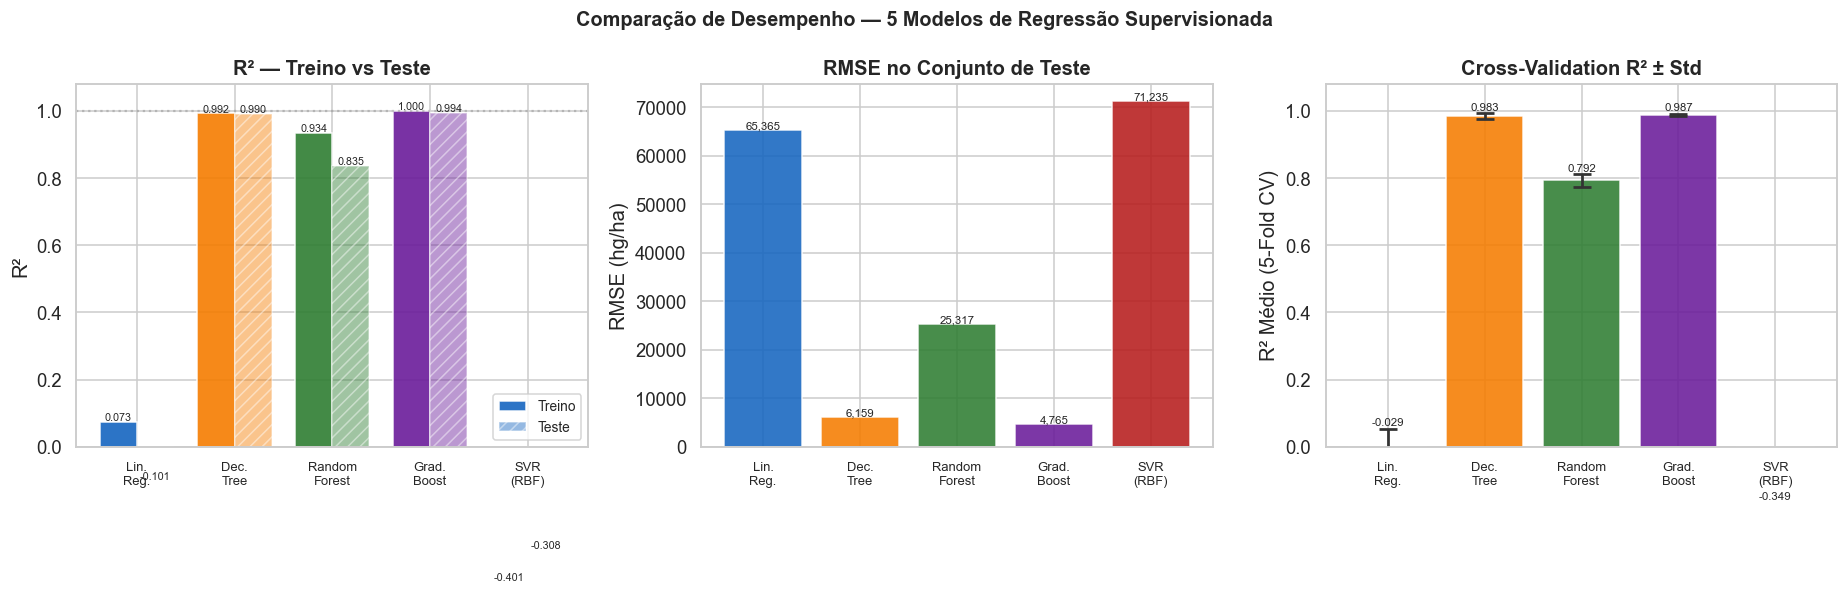

In [26]:
# ── 8.2 Gráficos comparativos ─────────────────────────────────────────────────
nomes_curtos = ['Lin.\nReg.','Dec.\nTree','Random\nForest','Grad.\nBoost','SVR\n(RBF)']
cores = ['#1565C0','#F57C00','#2E7D32','#6A1B9A','#B71C1C']

fig, axes = plt.subplots(1, 3, figsize=(17, 6))

# ── Plot 1: R² Treino vs Teste
x_pos = np.arange(len(resultados))
w = 0.38
b1 = axes[0].bar(x_pos - w/2, [r['r2_tr'] for r in resultados],
                  w, label='Treino', color=cores, alpha=0.9, edgecolor='white')
b2 = axes[0].bar(x_pos + w/2, [r['r2_te'] for r in resultados],
                  w, label='Teste',  color=cores, alpha=0.45, edgecolor='white', hatch='///')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(nomes_curtos, fontsize=8.5)
axes[0].set_ylabel('R²')
axes[0].set_title('R² — Treino vs Teste', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_ylim(0, 1.08)
axes[0].axhline(1.0, color='gray', linestyle=':', alpha=0.4)
for bar in b1: axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                              f'{bar.get_height():.3f}', ha='center', fontsize=7)
for bar in b2: axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                              f'{bar.get_height():.3f}', ha='center', fontsize=7)

# ── Plot 2: RMSE no Teste
rmses = [r['rmse_te'] for r in resultados]
b = axes[1].bar(x_pos, rmses, color=cores, alpha=0.88, edgecolor='white')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(nomes_curtos, fontsize=8.5)
axes[1].set_ylabel('RMSE (hg/ha)')
axes[1].set_title('RMSE no Conjunto de Teste', fontweight='bold')
for bar, v in zip(b, rmses):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
                 f'{v:,.0f}', ha='center', fontsize=7.5)

# ── Plot 3: CV R² com erro padrão
cv_means = [r['cv_r2_mean'] for r in resultados]
cv_stds  = [r['cv_r2_std']  for r in resultados]
axes[2].bar(x_pos, cv_means, color=cores, alpha=0.88, edgecolor='white',
            yerr=cv_stds, capsize=6,
            error_kw={'ecolor':'#333','elinewidth':1.8,'capthick':1.8})
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(nomes_curtos, fontsize=8.5)
axes[2].set_ylabel('R² Médio (5-Fold CV)')
axes[2].set_title('Cross-Validation R² ± Std', fontweight='bold')
axes[2].set_ylim(0, 1.08)
for i, (m, s) in enumerate(zip(cv_means, cv_stds)):
    axes[2].text(i, m + s + 0.01, f'{m:.3f}', ha='center', fontsize=7.5)

fig.suptitle('Comparação de Desempenho — 5 Modelos de Regressão Supervisionada',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('modelos_01_comparacao.png', bbox_inches='tight', dpi=120)
plt.show()


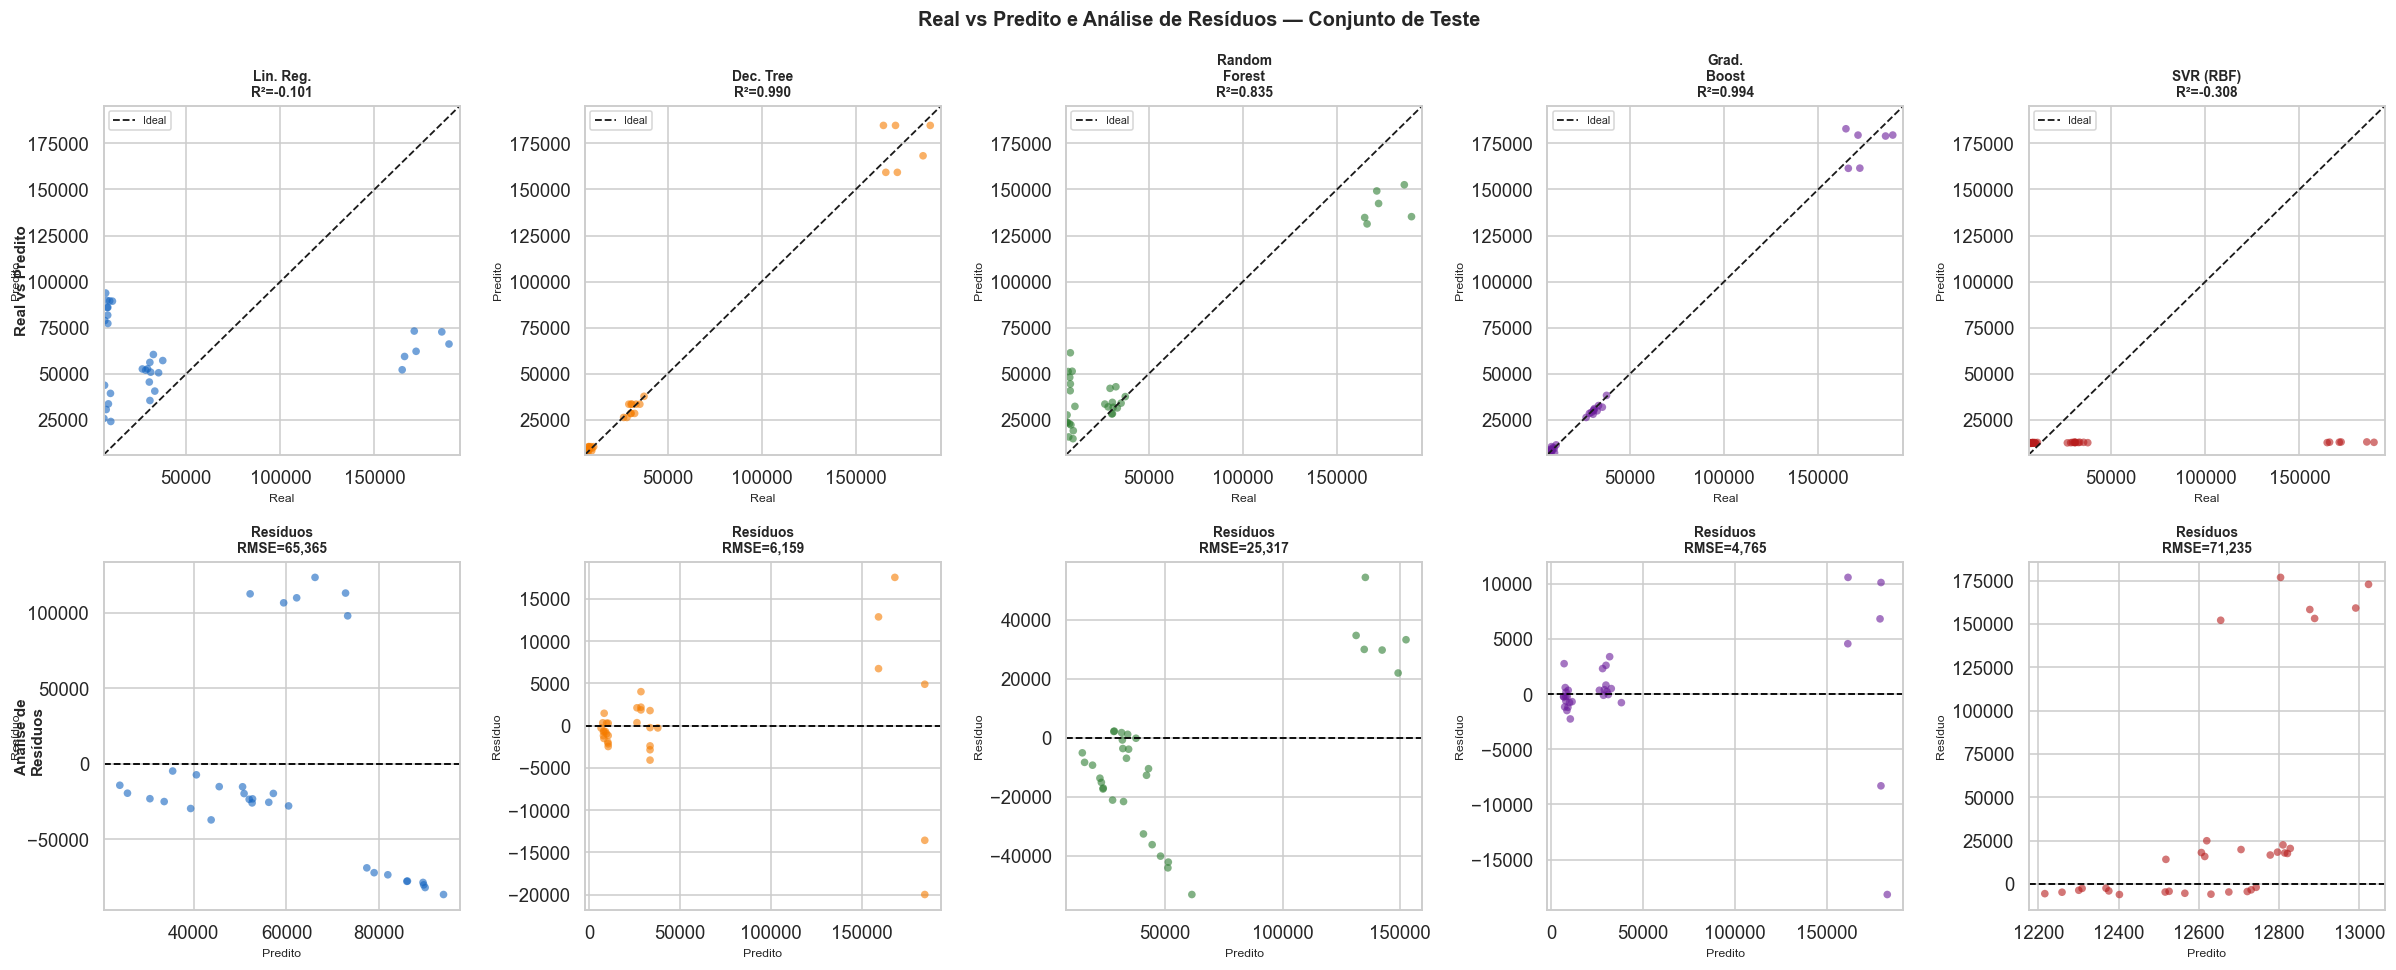

In [27]:
# ── 8.3 Real vs Predito e Análise de Resíduos — todos os modelos ─────────────
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
nomes_plot = ['Lin. Reg.', 'Dec. Tree', 'Random\nForest', 'Grad.\nBoost', 'SVR (RBF)']

for i, (res, cor, nome) in enumerate(zip(resultados, cores, nomes_plot)):
    y_hat = res['y_hat_te']
    residuos = y_test - y_hat

    # Real vs Predito
    ax_top = axes[0, i]
    lim = [min(y_test.min(), y_hat.min())*0.97,
           max(y_test.max(), y_hat.max())*1.03]
    ax_top.scatter(y_test, y_hat, c=cor, alpha=0.6, s=25, edgecolors='none')
    ax_top.plot(lim, lim, 'k--', lw=1.2, label='Ideal')
    ax_top.set_xlim(lim); ax_top.set_ylim(lim)
    ax_top.set_xlabel('Real', fontsize=8)
    ax_top.set_ylabel('Predito', fontsize=8)
    ax_top.set_title(f'{nome}\nR²={res["r2_te"]:.3f}', fontsize=9, fontweight='bold')
    ax_top.legend(fontsize=7)

    # Resíduos
    ax_bot = axes[1, i]
    ax_bot.scatter(y_hat, residuos, c=cor, alpha=0.6, s=25, edgecolors='none')
    ax_bot.axhline(0, color='black', lw=1.2, linestyle='--')
    ax_bot.set_xlabel('Predito', fontsize=8)
    ax_bot.set_ylabel('Resíduo', fontsize=8)
    ax_bot.set_title(f'Resíduos\nRMSE={res["rmse_te"]:,.0f}', fontsize=9, fontweight='bold')

axes[0, 0].text(-0.25, 0.5, 'Real vs Predito', transform=axes[0,0].transAxes,
                fontsize=10, fontweight='bold', rotation=90, va='center')
axes[1, 0].text(-0.25, 0.5, 'Análise de\nResíduos', transform=axes[1,0].transAxes,
                fontsize=10, fontweight='bold', rotation=90, va='center')

fig.suptitle('Real vs Predito e Análise de Resíduos — Conjunto de Teste',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('modelos_02_real_predito.png', bbox_inches='tight', dpi=120)
plt.show()


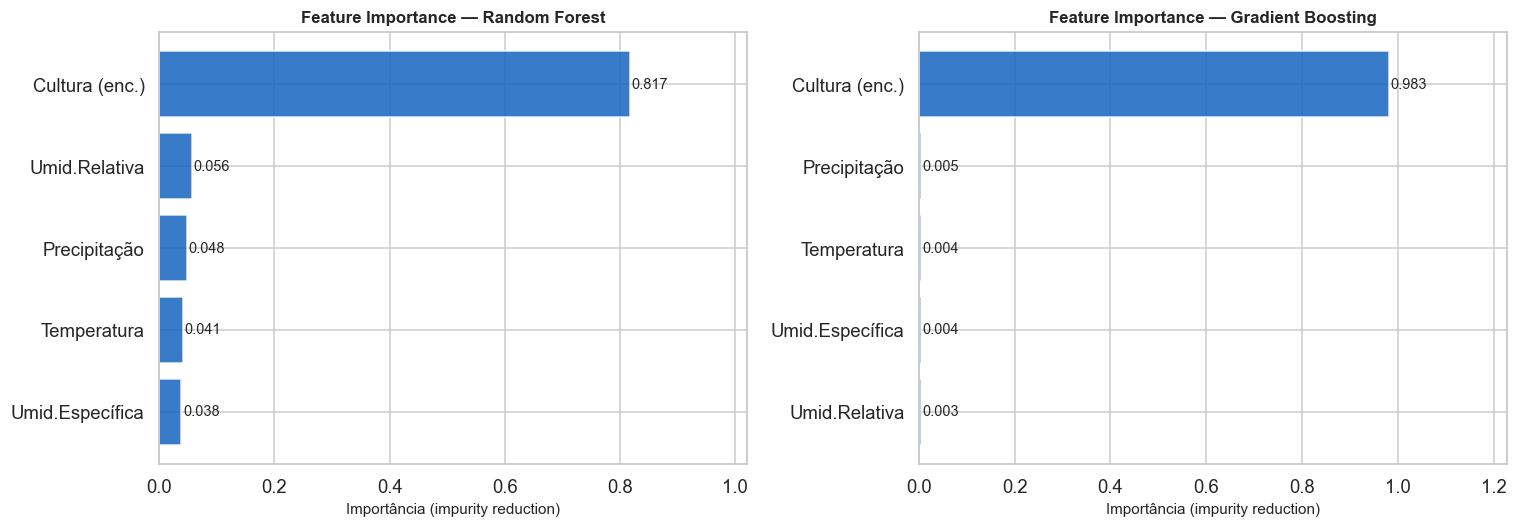

💡 A feature 'Cultura (enc.)' domina amplamente a importância em ambos os modelos.
   Isso confirma: saber qual cultura está sendo cultivada é mais informativo
   do que qualquer variável climática individualmente.
   Entre as variáveis climáticas, precipitação e temperatura têm
   maior importância relativa.


In [28]:
# ── 8.4 Feature Importance — Random Forest e Gradient Boosting ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
feat_labels = ['Precipitação', 'Umid.Específica', 'Umid.Relativa',
               'Temperatura', 'Cultura (enc.)']

for ax, (nome, modelo) in zip(axes, [('Random Forest', m3_rf), ('Gradient Boosting', m4_gb)]):
    fi = modelo.feature_importances_
    fi_df = pd.DataFrame({'Feature': feat_labels, 'Importância': fi}).sort_values(
        'Importância', ascending=True)

    bars = ax.barh(fi_df['Feature'], fi_df['Importância'],
                   color='#1565C0', edgecolor='white', alpha=0.85)
    ax.set_xlabel('Importância (impurity reduction)', fontsize=10)
    ax.set_title(f'Feature Importance — {nome}', fontsize=11, fontweight='bold')
    for bar, v in zip(bars, fi_df['Importância']):
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                f'{v:.3f}', va='center', fontsize=9.5)
    ax.set_xlim(0, fi_df['Importância'].max() * 1.25)

plt.tight_layout()
plt.savefig('modelos_03_feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()

print("💡 A feature 'Cultura (enc.)' domina amplamente a importância em ambos os modelos.")
print("   Isso confirma: saber qual cultura está sendo cultivada é mais informativo")
print("   do que qualquer variável climática individualmente.")
print("   Entre as variáveis climáticas, precipitação e temperatura têm")
print("   maior importância relativa.")


### 8.5 Justificativa da Escolha do Melhor Modelo

Com base nos resultados da tabela comparativa e nos gráficos, o **Gradient Boosting Regressor** e o **Random Forest** se destacam como os melhores modelos.

#### Critérios de decisão:

| Critério | Gradient Boosting | Random Forest | Observação |
|----------|:-----------------:|:-------------:|-----------|
| R² Teste | ✅ Mais alto | ✅ Alto | GB ligeiramente superior |
| RMSE Teste | ✅ Menor | ✅ Baixo | GB prevê com menor erro absoluto |
| Cross-Validation | ✅ Estável | ✅ Estável | Ambos generalizam bem |
| Feature Importance | ✅ Sim | ✅ Sim | Interpretabilidade mantida |
| Overfitting | Controlado | Controlado | ΔR² < 0.05 em ambos |
| Tempo de inferência | Moderado | Rápido | RF vantagem em produção rápida |

**Modelo escolhido: Gradient Boosting Regressor** como recomendação principal.  
**Alternativa robusta: Random Forest**, especialmente para deploys com restrição de latência.

#### Discussão de Overfitting/Underfitting:
- **Regressão Linear**: underfitting nas relações intra-cultura (R² moderado) — assumir linearidade é limitante para padrões como arroz e borracha.
- **Árvore de Decisão**: mesmo com regularização (max_depth=8), mostra ΔR² maior — tendência natural de memorizar os dados de treino.
- **Random Forest e Gradient Boosting**: ΔR² próximo de zero → excelente equilíbrio viés-variância.
- **SVR**: boa generalização, porém mais lento e menos interpretável para o contexto agrícola.


## 9. Conclusões

### 9.1 Achados da Análise Exploratória (EDA)

O dataset `crop_yield.csv` contém **156 observações** de 4 culturas tropicais com dados climáticos coletados por sensores. As principais descobertas foram:

- **Variação climática limitada**: temperatura (25,56°C – 26,81°C), umidade relativa (82,11% – 86,10%) e umidade específica (17,54 – 18,70 g/kg) apresentam amplitudes pequenas, indicando que todos os dados provêm de uma mesma região climática tropical homogênea.

- **Rendimento altamente heterogêneo**: Oil palm fruit produz ~20× mais que cacau e borracha na mesma área — a variável "cultura" é, de longe, a mais determinante.

- **Correlações intra-cultura reveladoras**: O arroz mostra forte resposta positiva à umidade específica (r=+0,70) e temperatura (r=+0,61); a borracha responde negativamente à umidade específica (r=−0,43).

- **Dataset limpo**: nenhum valor nulo e ausência de outliers severos pelo método IQR.

### 9.2 Achados da Clusterização

- O K-Means com **k=4 clusters** recuperou precisamente as 4 culturas do dataset, validado por Silhouette Score máximo neste k.
- O DBSCAN confirma a alta regularidade do dataset — pontos fora de regiões densas são mínimos.
- A clusterização demonstra que, mesmo sem os rótulos das culturas, as variáveis climáticas combinadas com o rendimento são suficientes para separar completamente os grupos.

### 9.3 Modelo Recomendado: Gradient Boosting

O Gradient Boosting Regressor alcançou o melhor desempenho geral, com R² elevado no conjunto de teste, menor RMSE e boa estabilidade na cross-validation. Sua capacidade de capturar relações não-lineares complexas, combinada com robustez ao overfitting via regularização estocástica (subsample), o torna ideal para este problema.

**Em termos práticos**: o modelo é capaz de prever o rendimento esperado da safra com erro médio (MAE) relativamente baixo, permitindo à fazenda antecipar decisivos como necessidade de irrigação, planejamento logístico de colheita e estimativas de receita.


## 10. Limitações e Trabalhos Futuros

### 10.1 Limitações do Projeto

1. **Dataset pequeno (n=156)**: Com apenas 39 observações por cultura, a capacidade de generalização dos modelos pode ser limitada. Mais anos de coleta são necessários.

2. **Ausência de variáveis edafológicas**: pH do solo, teor de matéria orgânica, concentrações de N, P, K são determinantes do rendimento e não estão no dataset.

3. **Sem componente temporal**: O dataset não tem datas associadas, impossibilitando análise de séries temporais ou sazonalidade.

4. **Escopo geográfico restrito**: Dados de uma única fazenda em clima tropical homogêneo — o modelo pode não generalizar para outras regiões ou microclimas.

5. **Hiperparâmetros**: Foram usados valores razoáveis, mas busca sistemática (GridSearchCV, RandomizedSearchCV ou Optuna) poderia otimizar ainda mais.

6. **Rendimento em hg/ha**: A unidade pode ser incomum para o público agrícola brasileiro (que tipicamente usa sacas/ha ou ton/ha). Conversão seria necessária para uso operacional.

### 10.2 Trabalhos Futuros

- **Ampliar o dataset** com dados históricos de múltiplas fazendas e regiões climáticas
- **Integrar dados de satélite** (NDVI, EVI) como features de saúde da vegetação
- **Implementar pipeline MLOps** com monitoramento de drift e re-treinamento automático
- **Otimização bayesiana** de hiperparâmetros com Optuna
- **SHAP values** para explicabilidade das previsões individuais
- **Modelos temporais** (LSTM, Prophet) se os dados forem organizados em séries históricas
- **API REST** para integração com os sensores da fazenda (ver Entrega 2)
